# (17) Kyoto16: residual error look whitened?

host = ```mach```, device = ```cuda:3```

**Motivation**: <br>

using this model: gaussian-sigmoid: z-256, (16, 32.0)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


from analysis.fourier import power_spectrum_2d


def _plot_selected_samples(select_from=None, ncols=30, seed=0):
    rng = get_rng(seed)

    nrows = 4
    fig, axes = create_figure(nrows, ncols, (1 * ncols + 0.1, 1 * nrows), 'all', 'all')

    select_from = order[:200] if select_from is None else select_from
    selected_ids = rng.choice(select_from, size=ncols, replace=False)

    for i in range(ncols):
        idx = selected_ids[i]
        axes[0, i].imshow(tonp(true[idx]).reshape(16, 16), cmap='Greys_r')
        axes[1, i].imshow(tonp(pred[idx]).reshape(16, 16), cmap='Greys_r')
        axes[2, i].imshow(tonp(error[idx]).reshape(16, 16), cmap='Greys_r')
        axes[3, i].imshow(tonp(whitened[idx]).reshape(16, 16), cmap='Greys_r')
    
    axes[0, 0].set_ylabel('img', fontsize=15)
    axes[1, 0].set_ylabel('pred', fontsize=15)
    axes[2, 0].set_ylabel('error', fontsize=15)
    axes[3, 0].set_ylabel('whitened', fontsize=15)
    
    remove_ticks(axes, False)
    plt.show()


def _plot_sample_hists(num_samples=-1):
    fig, axes = create_figure(1, 3)
    sns.histplot(tonp(true[:num_samples]).ravel(), label='img', color='dimgrey', stat='percent', ax=axes[0])
    sns.histplot(tonp(pred[:num_samples]).ravel(), label='pred', color='C0', stat='percent', ax=axes[1])
    sns.histplot(tonp(error[:num_samples]).ravel(), label='error', color='C3', stat='percent', ax=axes[2])
    add_legend(axes)
    plt.show()


def _plot_power_spectrum(normalize=False, add_whitened=True):
    shape = (-1, *tr.model.cfg.input_sz)
    fig, axes = create_figure(1, 2, (8, 3.5), 'all', 'all')

    # true
    data = tr.to(true.reshape(shape))
    if normalize:
        data = (data - data.mean()) / data.std()
    radial_freq, radial_power = power_spectrum_2d(data)
    axes[0].loglog(radial_freq, radial_power, label='img', color='dimgrey', marker='o')
    axes[1].loglog(radial_freq, radial_power, label='img', color='dimgrey', marker='o')
    
    # whitened
    if add_whitened:
        data = tr.to(whitened.reshape(shape))
        if normalize:
            data = (data - data.mean()) / data.std()
        radial_freq, radial_power = power_spectrum_2d(data)
        axes[1].loglog(radial_freq, radial_power, label='whitened', color='C1', marker='o')

    # pred
    data = tr.to(pred.reshape(shape))
    if normalize:
        data = (data - data.mean()) / data.std()
    radial_freq, radial_power = power_spectrum_2d(data)
    axes[0].loglog(radial_freq, radial_power, label='pred', color='C0', marker='o')

    # error
    data = tr.to(error.reshape(shape))
    if normalize:
        data = (data - data.mean()) / data.std()
    radial_freq, radial_power = power_spectrum_2d(data)
    axes[0].loglog(radial_freq, radial_power, label='error', color='C3', marker='o')

    axes[0].set(xlabel='Spatial Frequency', ylabel='Power')
    axes[1].set(xlabel='Spatial Frequency')
    add_legend(axes)
    add_grid(axes)
    plt.show()

In [3]:
device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Load trainer

In [7]:
### (8, 16.0)  --- gold standard
# a = 'gaussian_sigmoid_Kyoto16_t-8_z-[256]_u-(7,2),du-(7,3)_<grad|lin>'
# b = 'b200-ep2000-lr(0.005)_beta(16:0.1)_gr(500)_(2025_03_20,18:27)'

### Best looking gompertz model
a = 'gaussian+gompertz_Kyoto16-bw_t-8_b-16_k-[128]_u-(7,2),du-(7,3)'
b = 'b200-ep2000-lr(0.005)_gr(300)_(2025_04_13,17:53)'

# a = 'gaussian+gompertz_Kyoto16-bw_t-32_b-64_k-[256]_u-(7,2),du-(7,3)'
# b = 'b200-ep2000-lr(0.005)_gr(300)_(2025_04_14,23:48)'

tr, meta = load_model(pjoin(a, b), device, strict=False)
meta['checkpoint']

2000

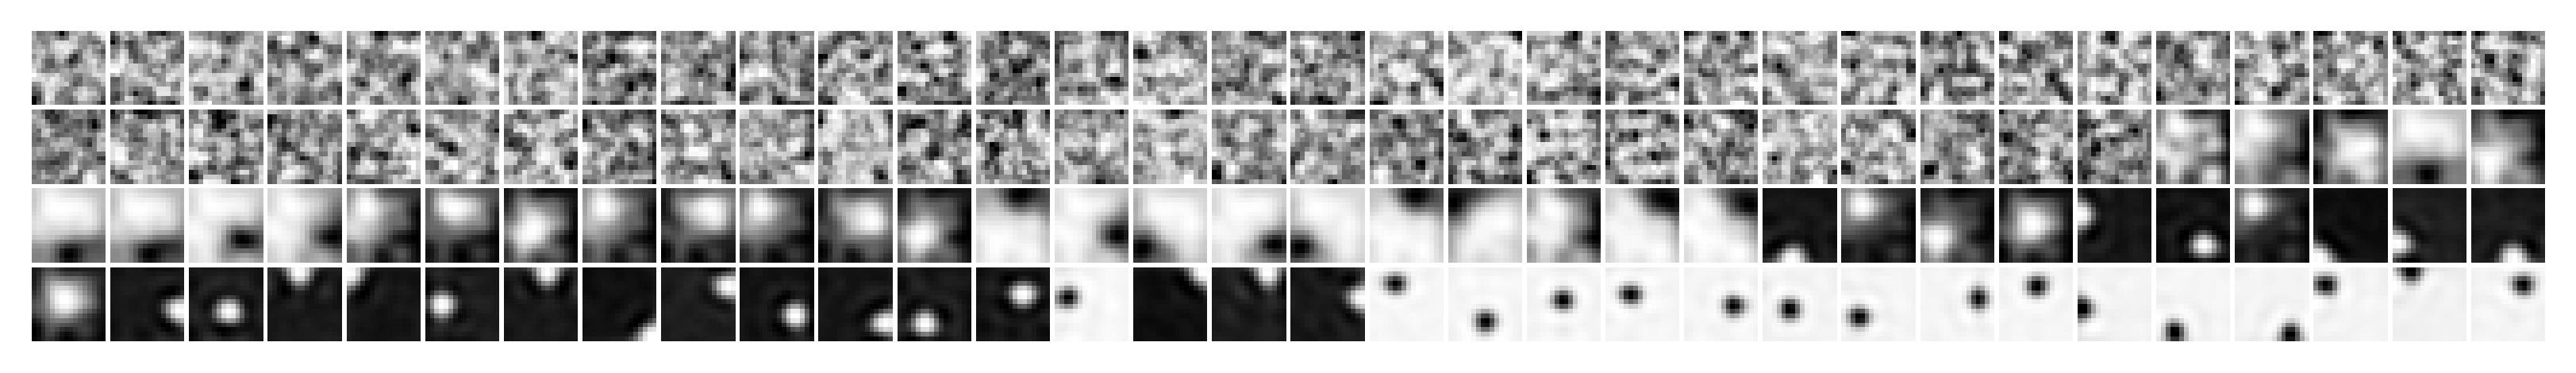

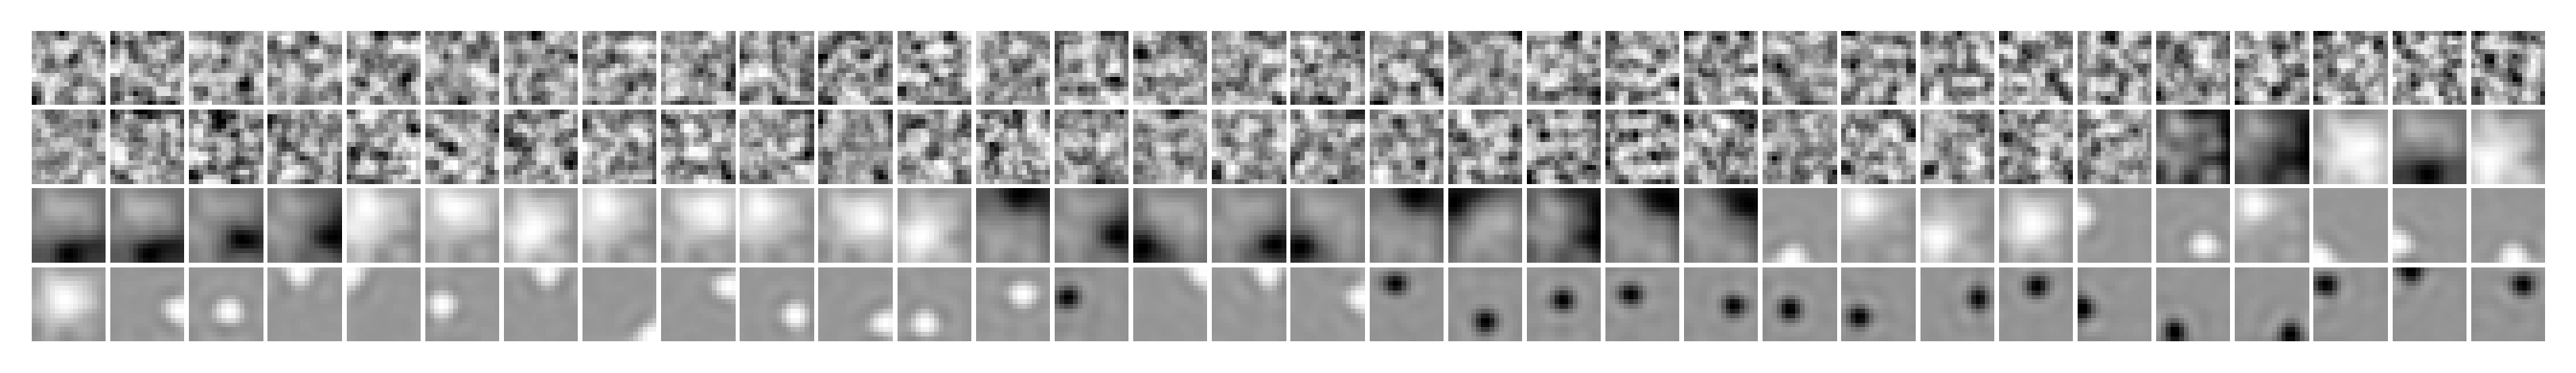

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=4, dpi=400)
tr.model.show(order=np.argsort(u0), nrows=4, dpi=400, method='abs-max');

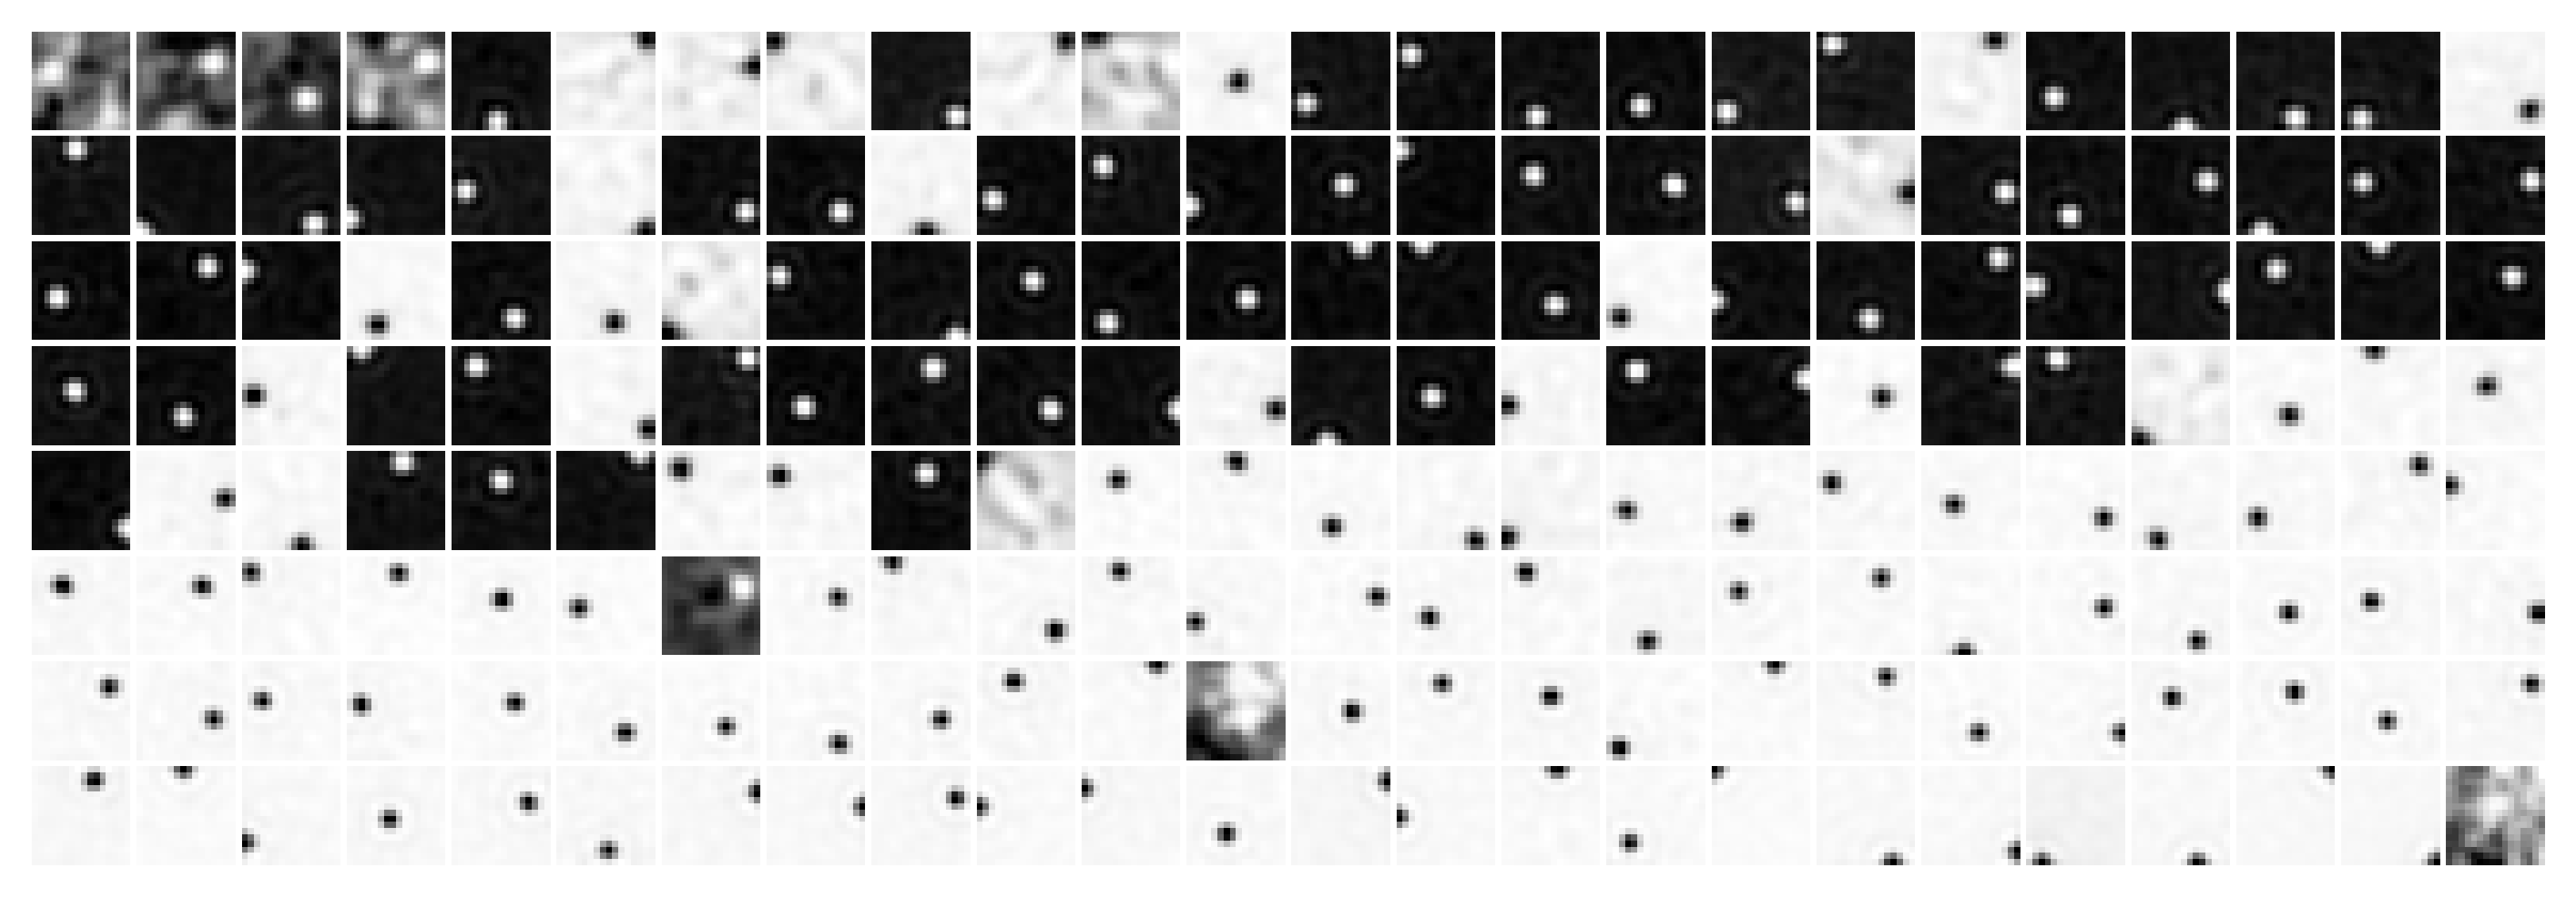

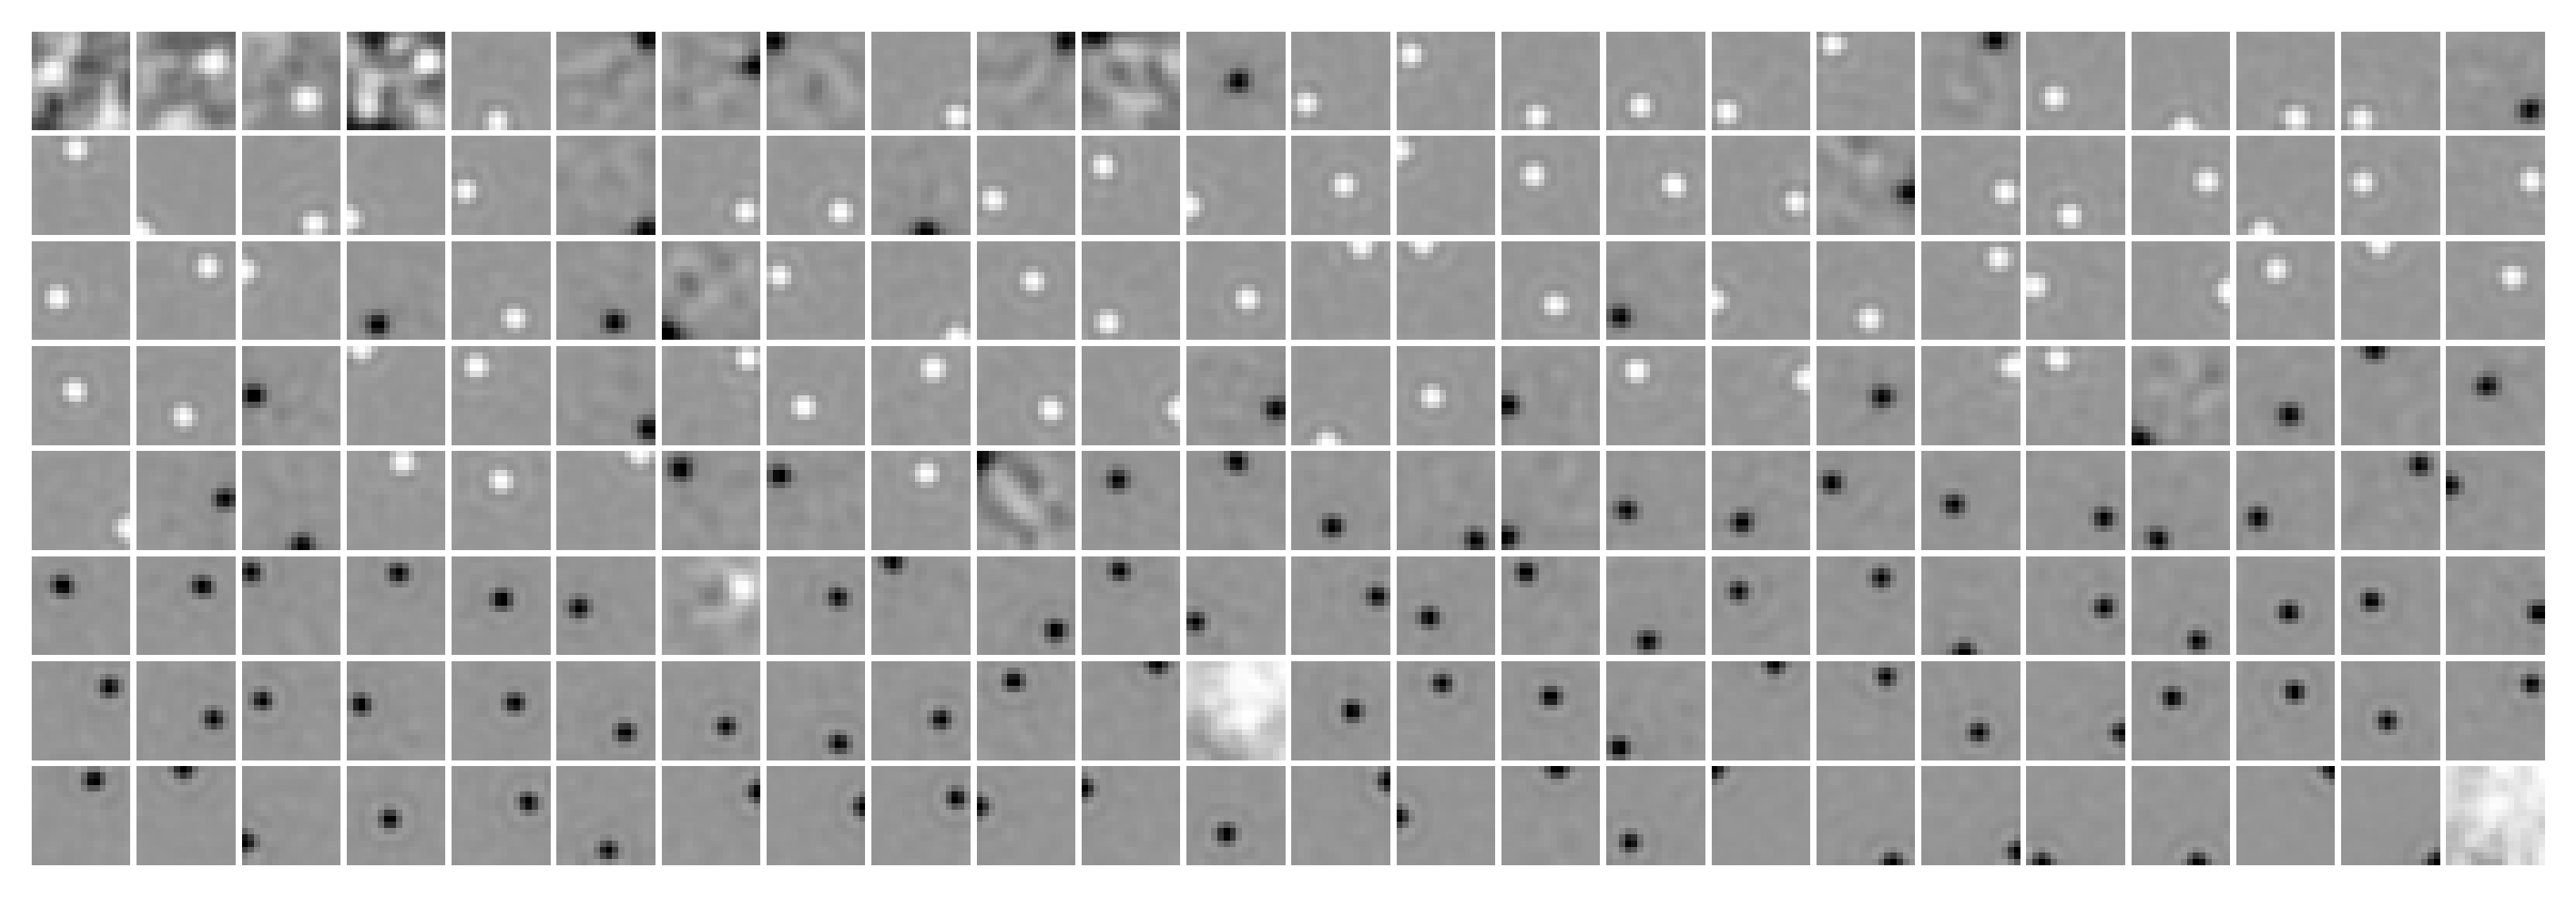

In [5]:
### Was: logistic

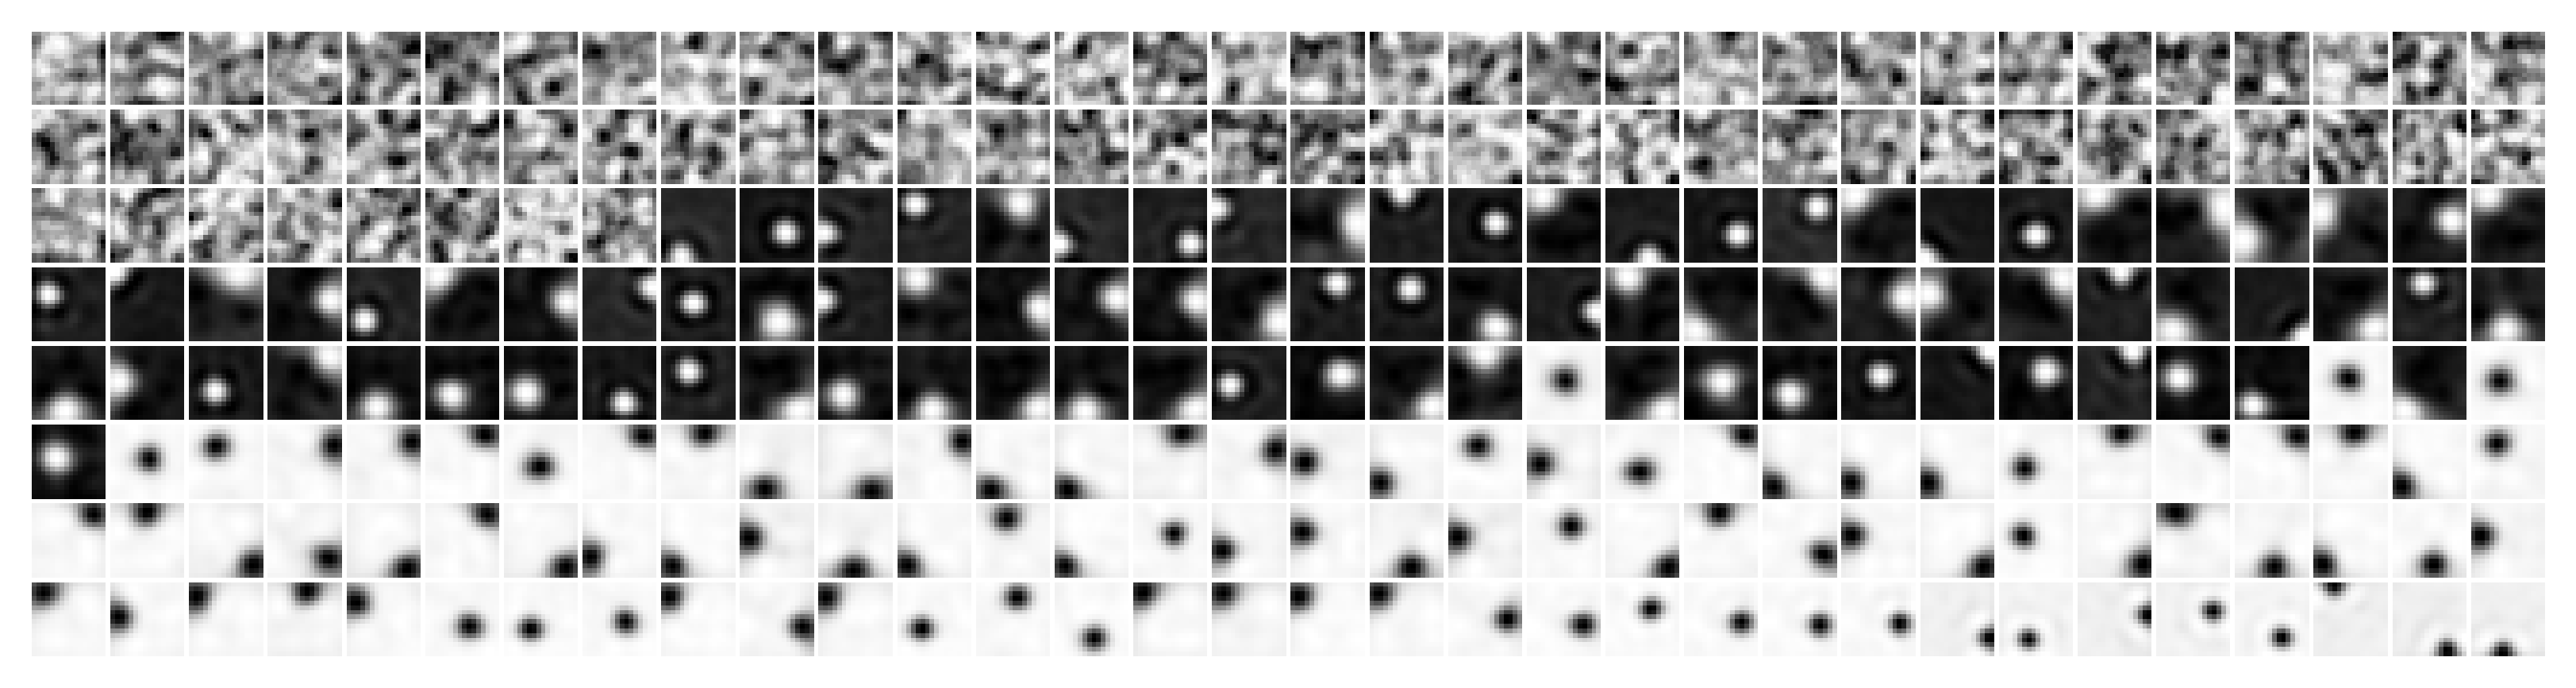

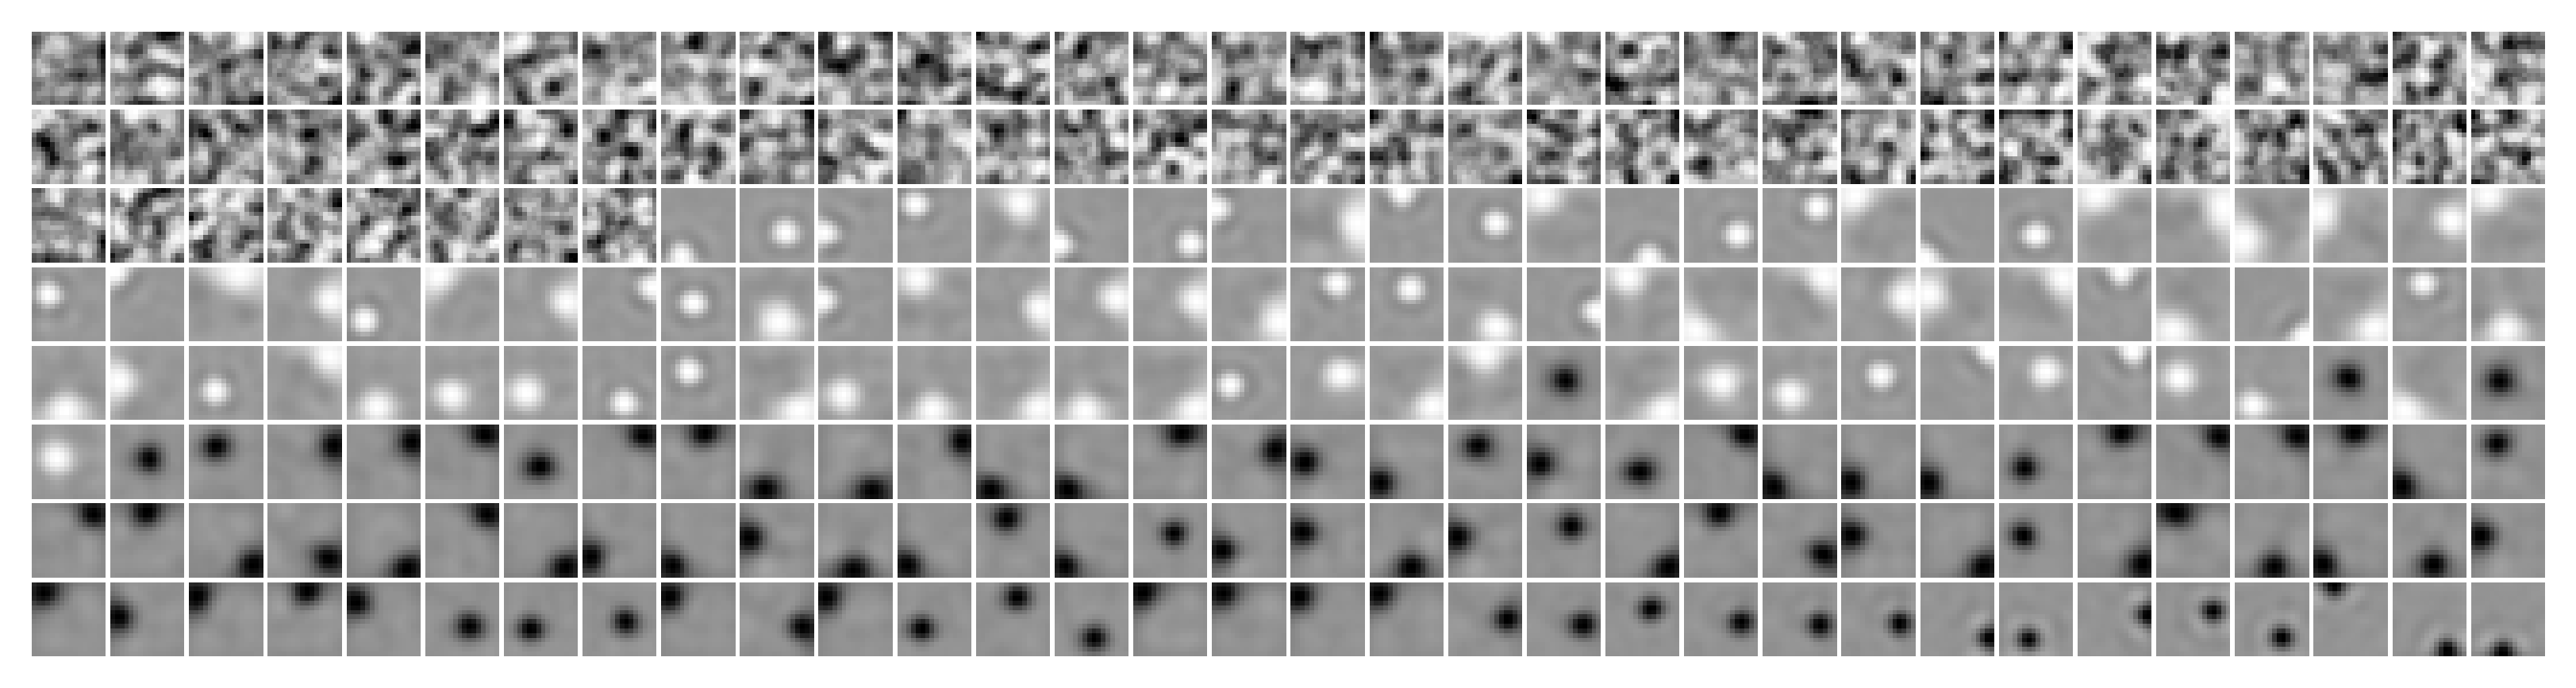

In [5]:
### Was: gold standard (8, 16.0, 256)

In [6]:
tr.cfg.batch_size = 3000
tr.setup_data()

In [7]:
%%time


t_total = 1000

true, pred, error = [], [], []
for x, *_ in tqdm(iter(tr.dl_vld)):
    feeder = tr.get_feeder(x)
    for t in range(t_total):
        tr.model.update_time(t)
        inpt = feeder[t]
        output = tr.model.xtract_ftr(inpt)

        if (t + 1) == t_total:
            true.append(inpt.flatten(start_dim=1))
            pred.append(tr.model.layer.conditional.loc)
            error.append(tr.model.layer.pred_error(
                x=inpt, weighted=False))

del output
torch.cuda.empty_cache()
import gc
gc.collect()

true = torch.cat(true)
pred = torch.cat(pred)
error = torch.cat(error)

error.shape

100%|█████████████████████████████████████████████| 4/4 [00:07<00:00,  1.76s/it]

CPU times: user 7.06 s, sys: 115 ms, total: 7.17 s
Wall time: 7.17 s


torch.Size([9821, 256])

In [8]:
# order: high contrast
var = tonp(torch.var(true, dim=1))
order = np.argsort(var)[::-1]

# get whitened data
_, whitened, _ = make_dataset('Kyoto16-wht', device)
whitened = whitened.tensors[0].flatten(start_dim=1)
whitened.shape

torch.Size([9821, 256])

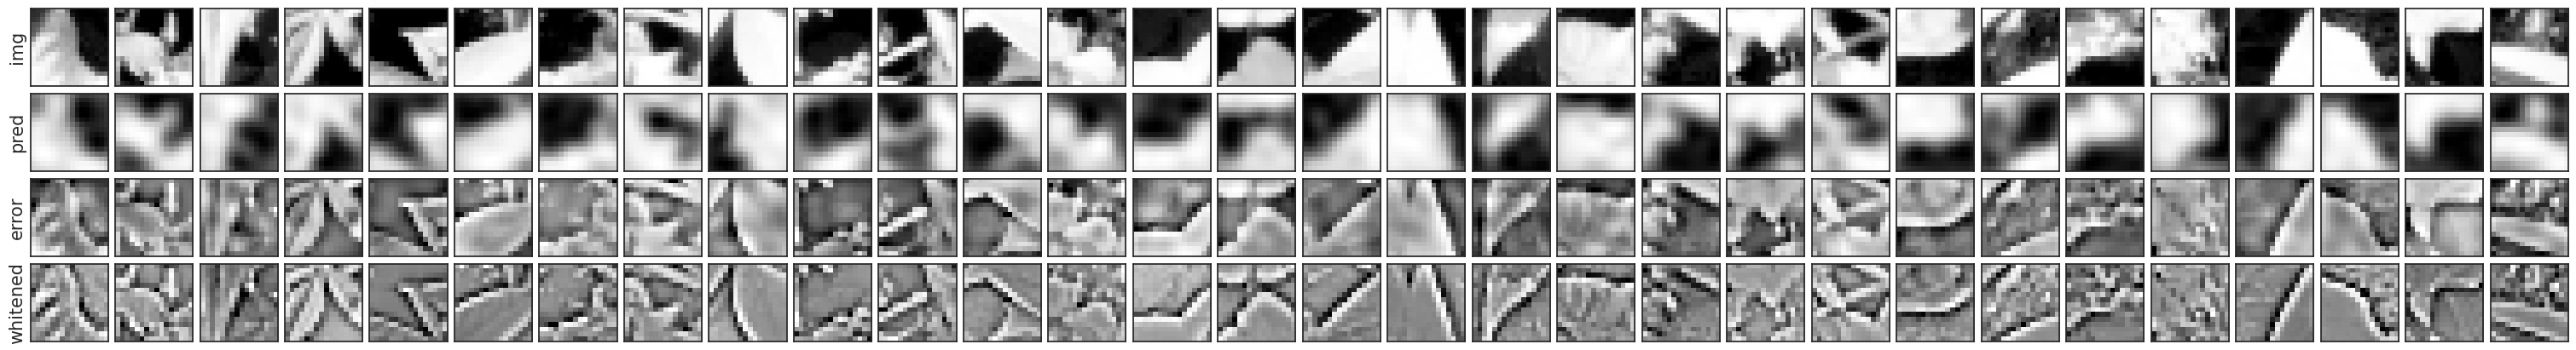

In [9]:
_plot_selected_samples()

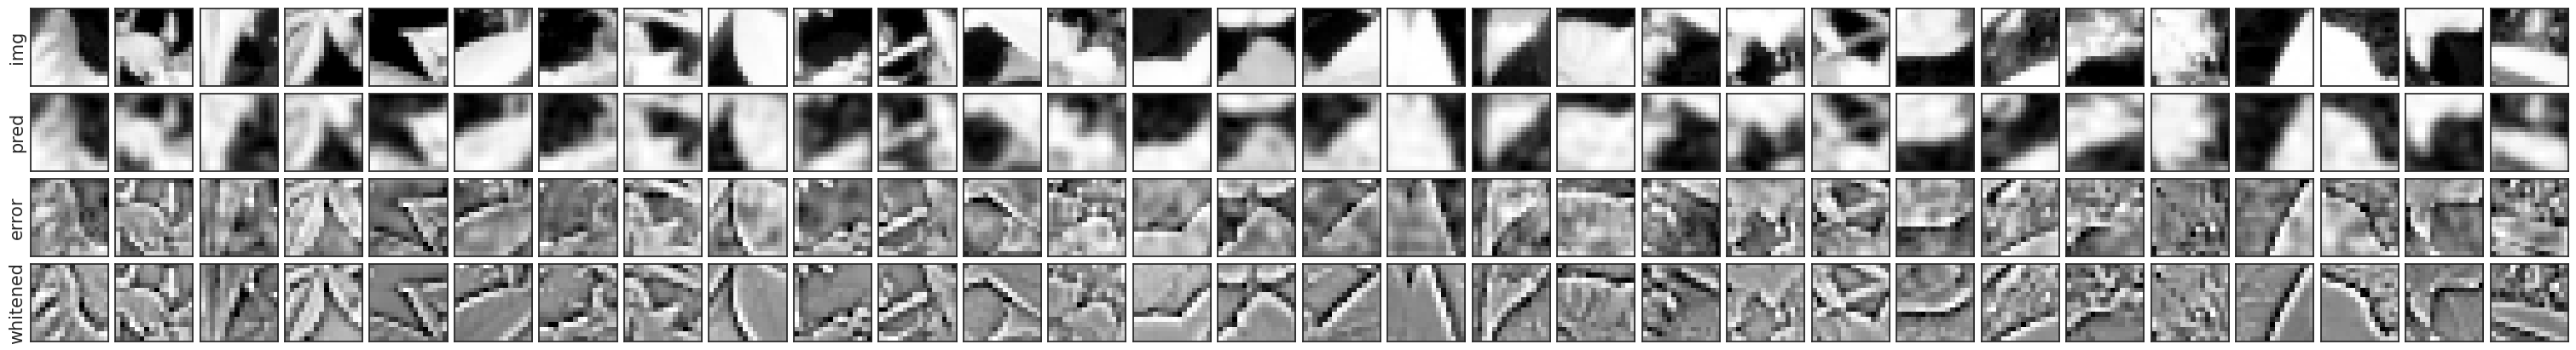

In [9]:
### Was: logistic

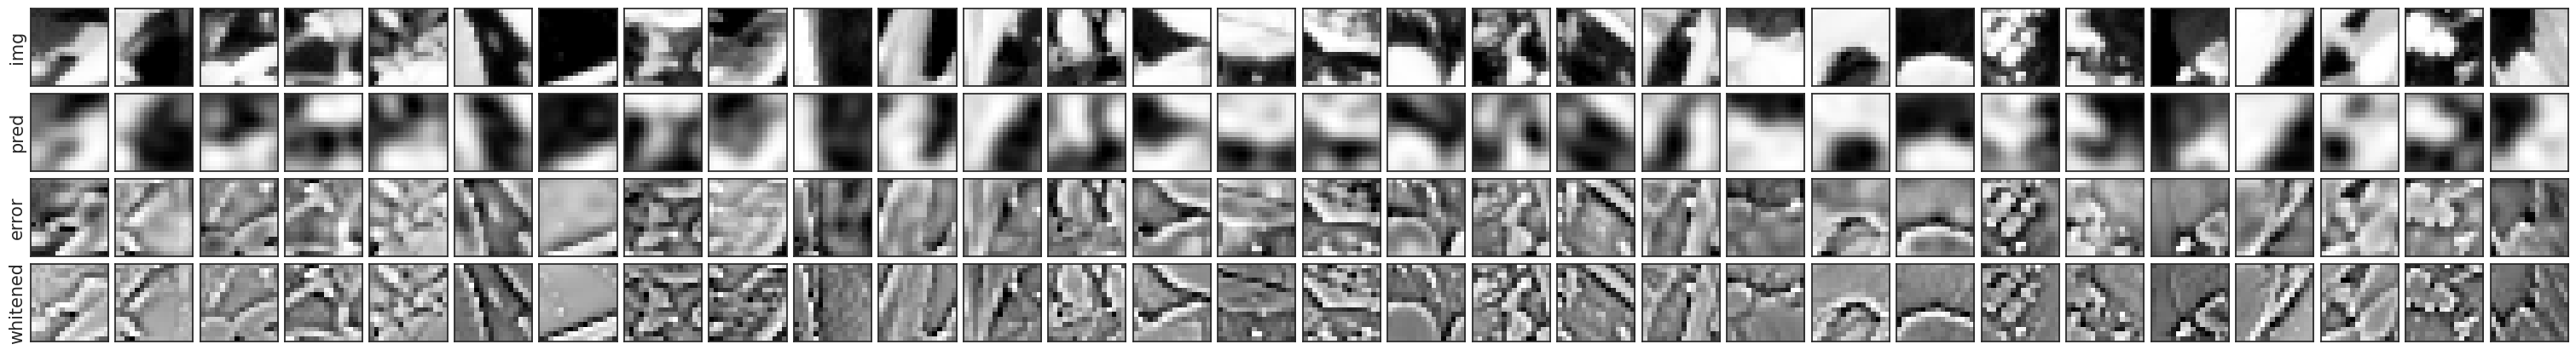

In [9]:
### Was: gold standard (8, 16.0, 256)

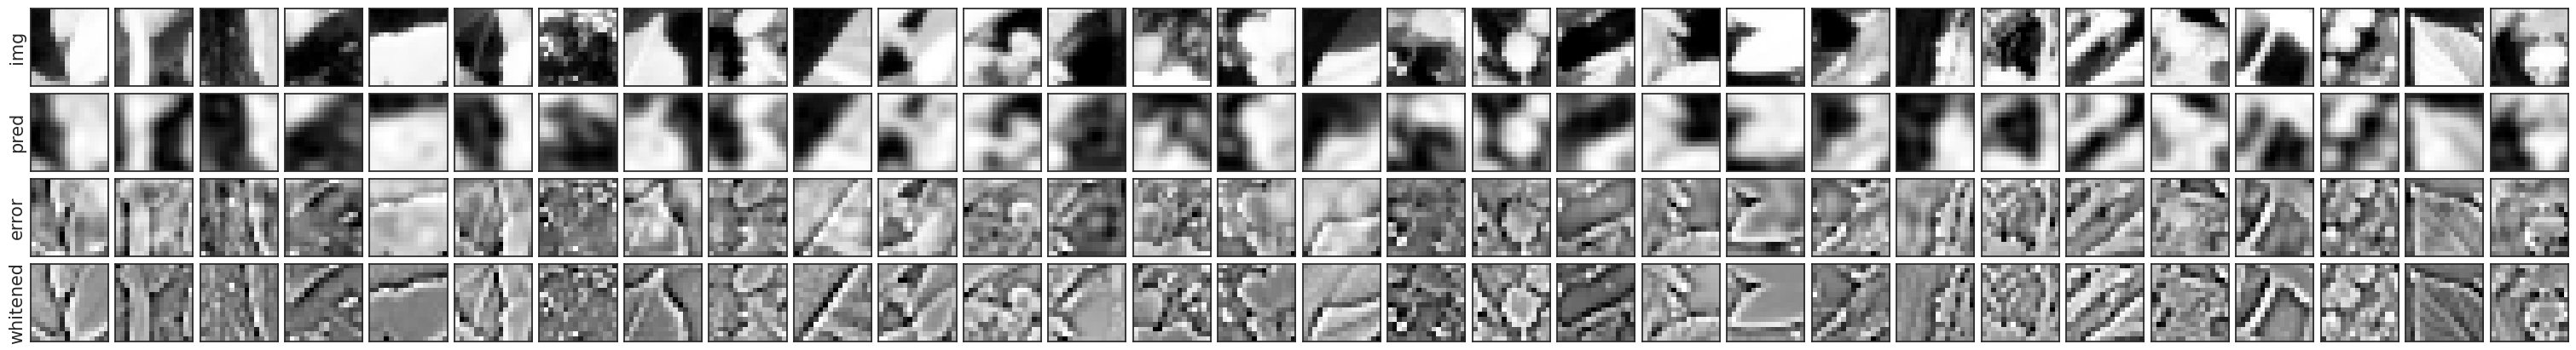

In [9]:
### Was: (16, 32.0)

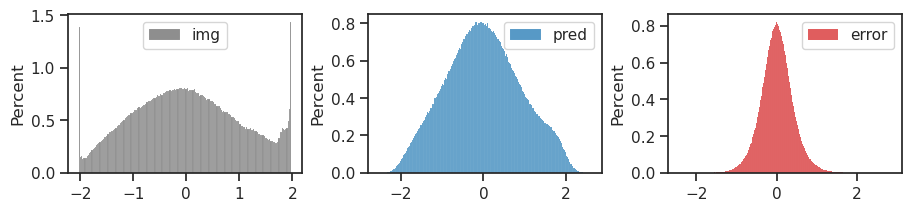

In [10]:
_plot_sample_hists()

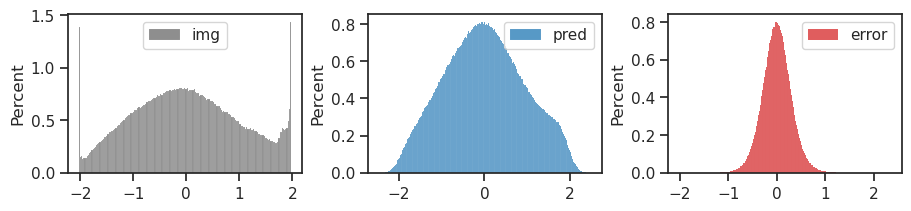

In [10]:
### Was: logistic

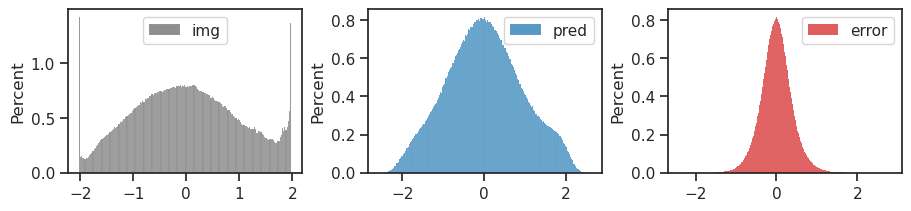

In [10]:
### Was: gold standard (8, 16.0, 256)

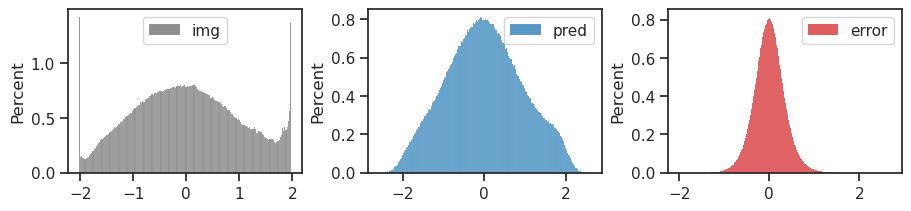

In [10]:
### Was: (16, 32.0)

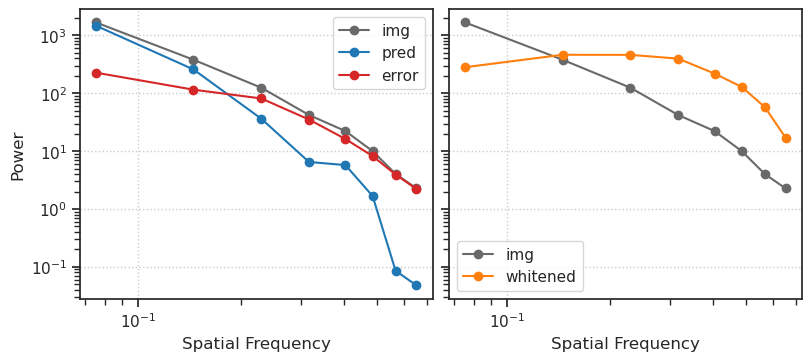

In [11]:
_plot_power_spectrum()

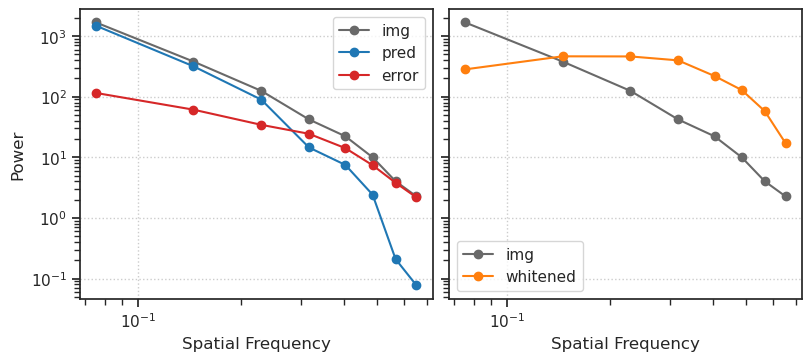

In [11]:
### Was: logistic

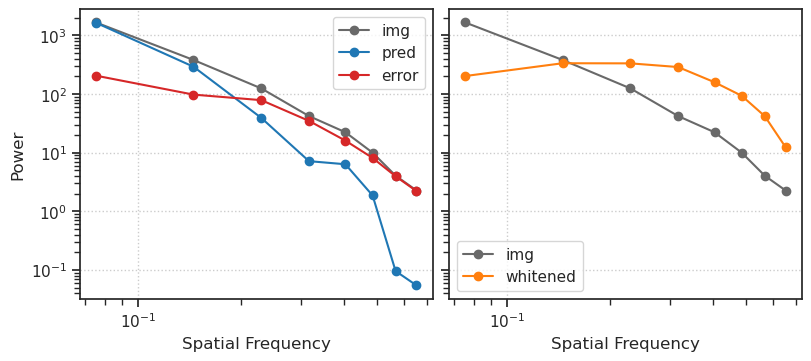

In [11]:
### Was: gold standard (8, 16.0, 256)

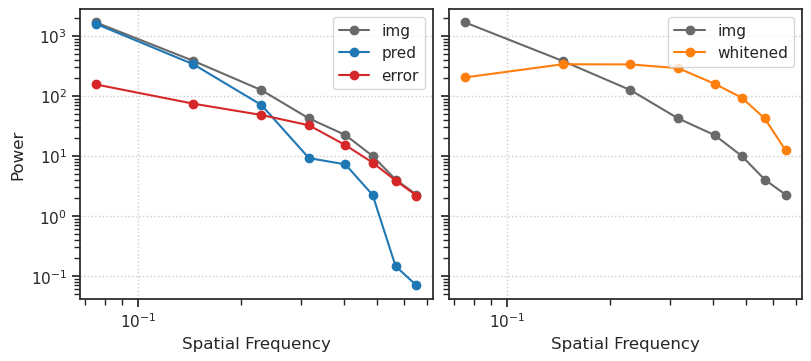

In [12]:
### Was: (16, 32.0)

## Activation params

In [12]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
gain = tonp(tr.model.layer.activation.log_gain.exp().squeeze())
b = tonp(tr.model.layer.activation.log_b.exp().squeeze())
c = tonp(tr.model.layer.activation.log_c.exp().squeeze())
# alpha = tonp(tr.model.layer.activation.log_alpha.exp().squeeze())
# beta = tonp(tr.model.layer.activation.beta.squeeze())

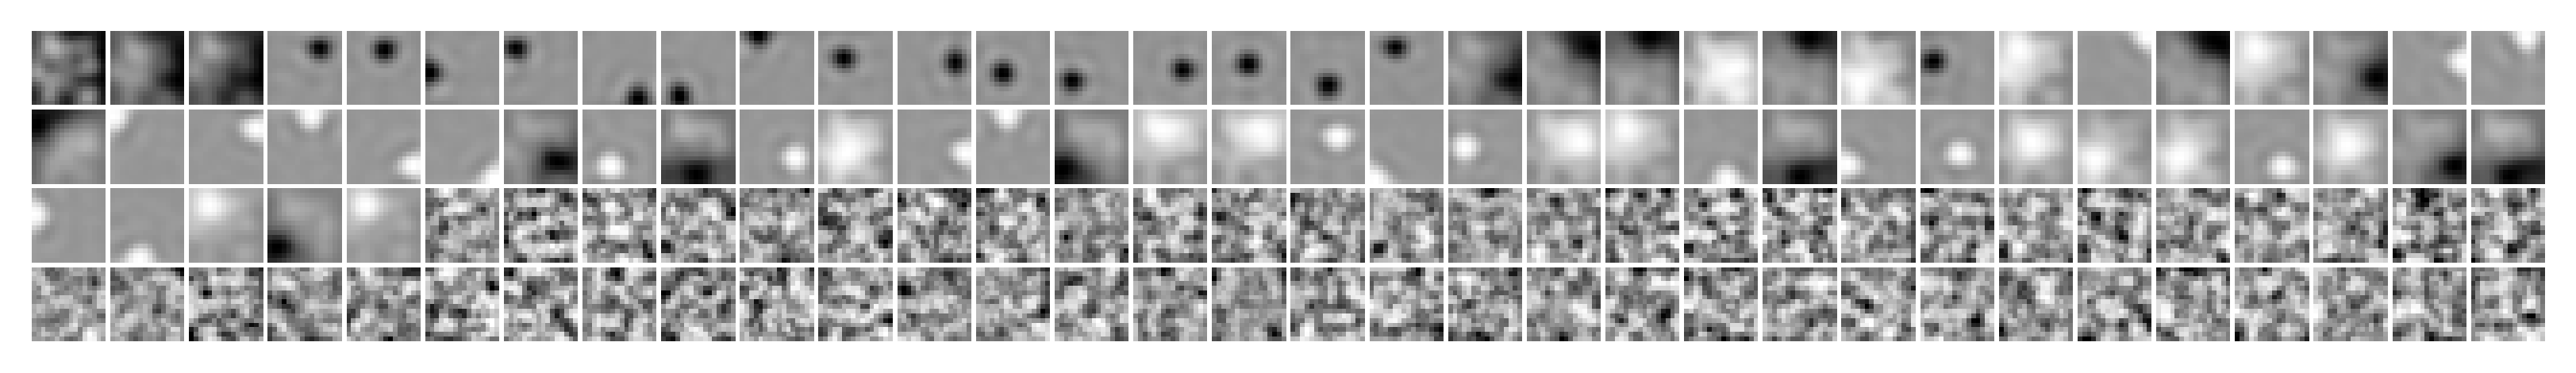

In [13]:
order = np.argsort(b)
tr.model.show(order=order, nrows=4, dpi=400, method='abs-max');

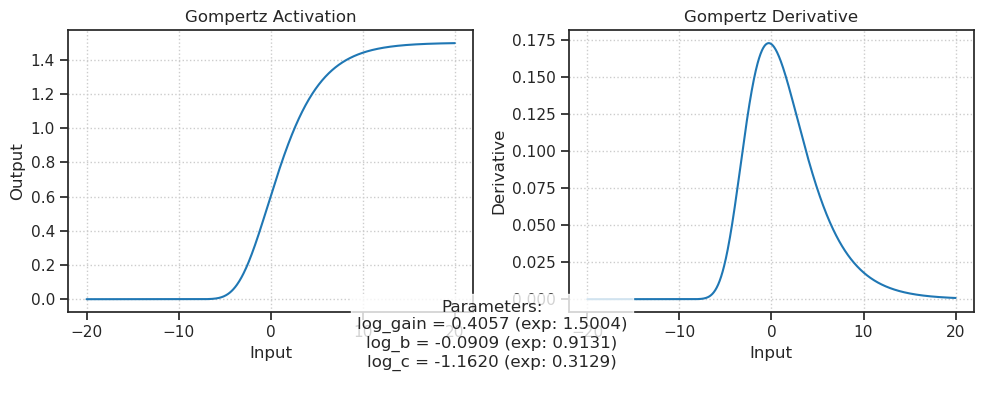

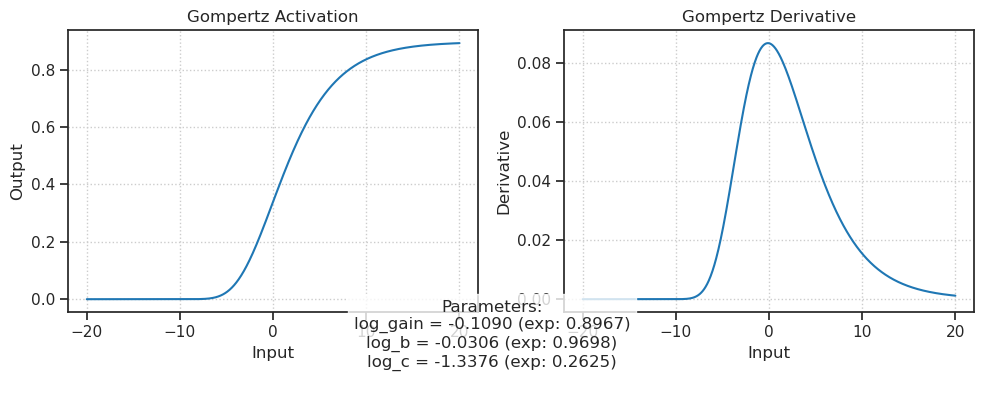

In [14]:
tr.model.layer.activation.show(order[4], x_range=(-20, 20));
tr.model.layer.activation.show(order[40], x_range=(-20, 20));

## Movie: first few t

```python
t in range(50)
```

In [59]:
# get whitened data
_, whitened, _ = make_dataset('Kyoto16', device)
whitened = whitened.tensors[0].flatten(start_dim=1)
whitened = whitened[torch.from_numpy(order.copy())]
whitened = whitened[:500]

error.shape, whitened.shape

(torch.Size([500, 256]), torch.Size([500, 256]))

In [60]:
# get stimulus
x = tr.dl_vld.dataset.tensors[0]
x = x[torch.from_numpy(order.copy())]
x = x[:500]
true = x.flatten(start_dim=1)

x.shape, true.shape

(torch.Size([500, 1, 16, 16]), torch.Size([500, 256]))

In [61]:
# xtract
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(x),
    seq=range(1000),
    return_extras=['conditional'],
).stack()

t = 0

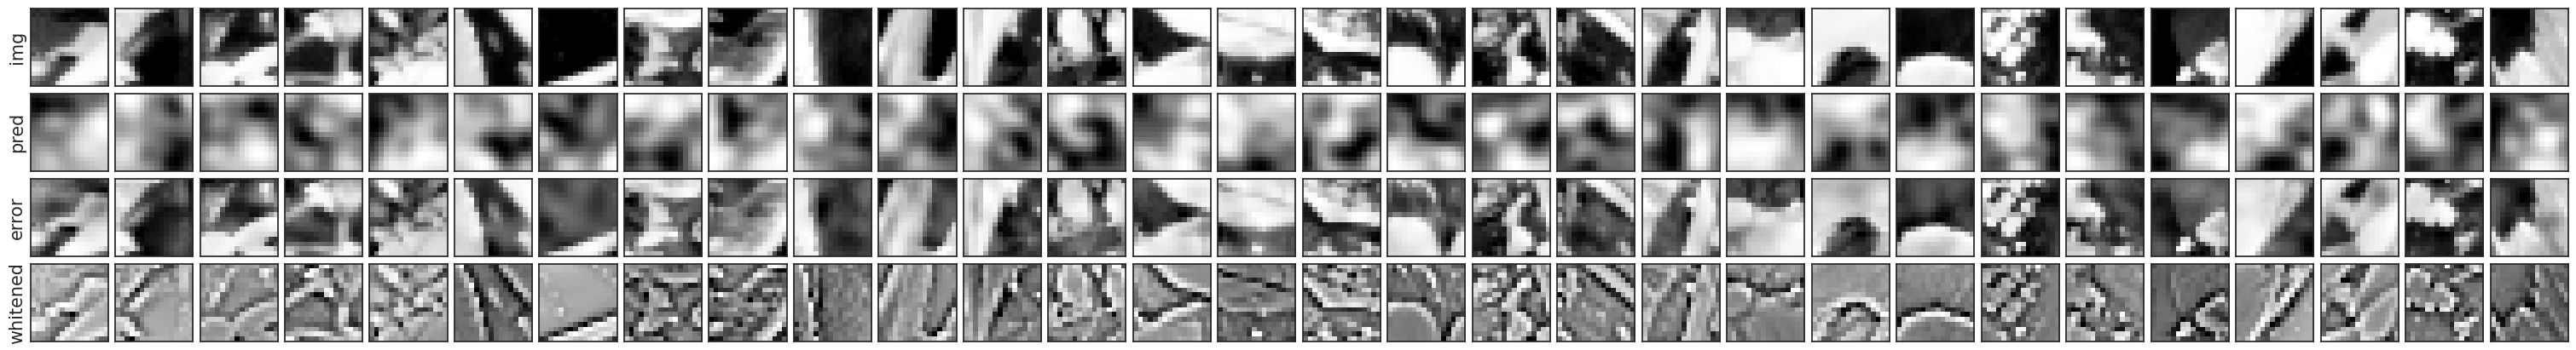

t = 1

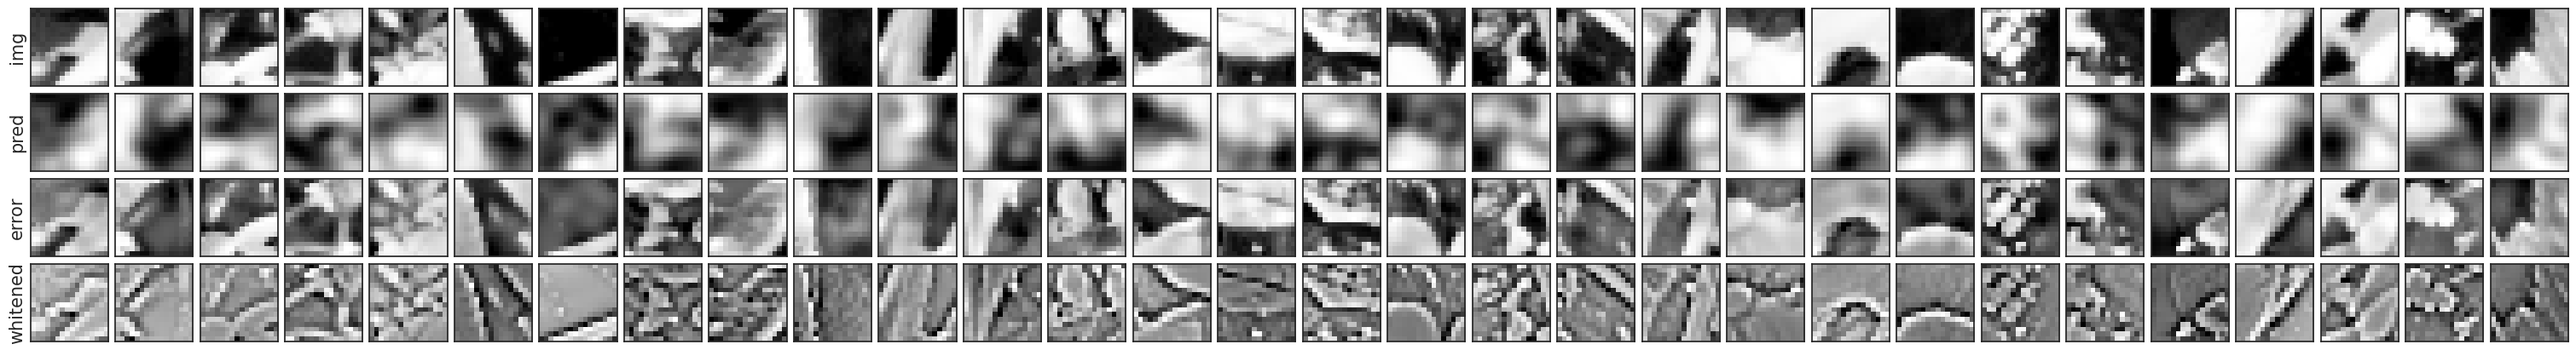

t = 2

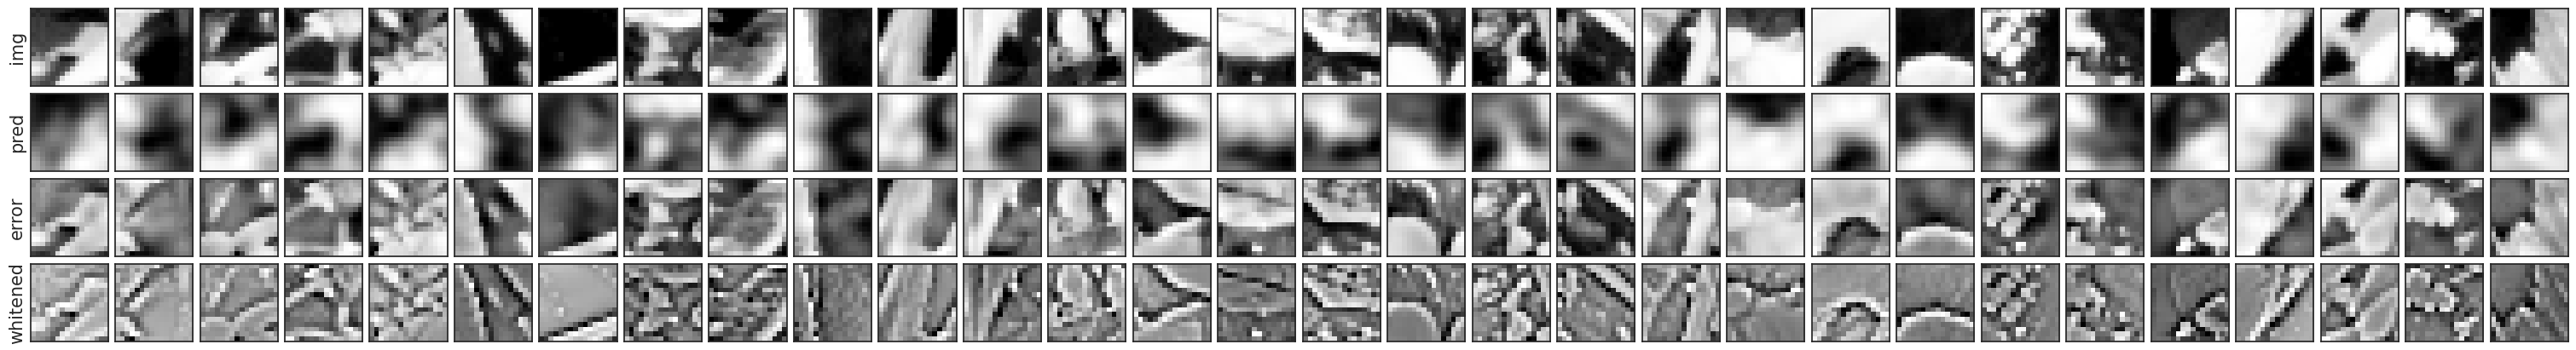

t = 3

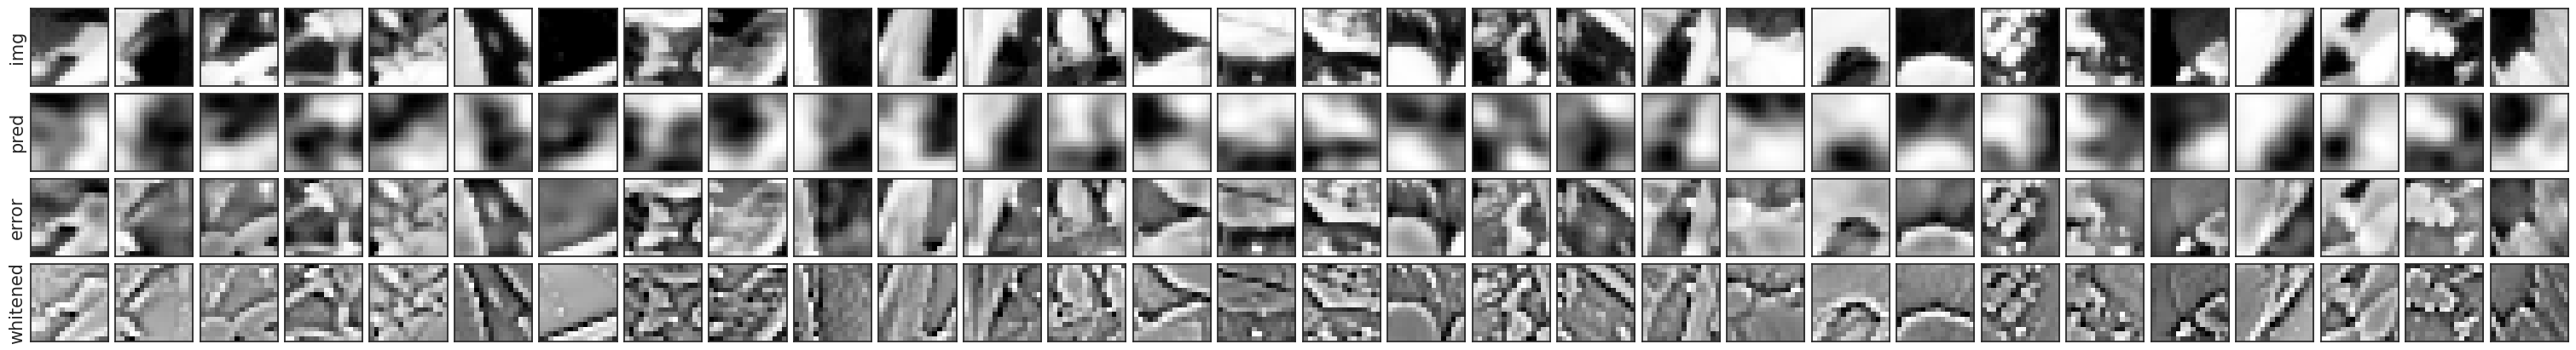

t = 4

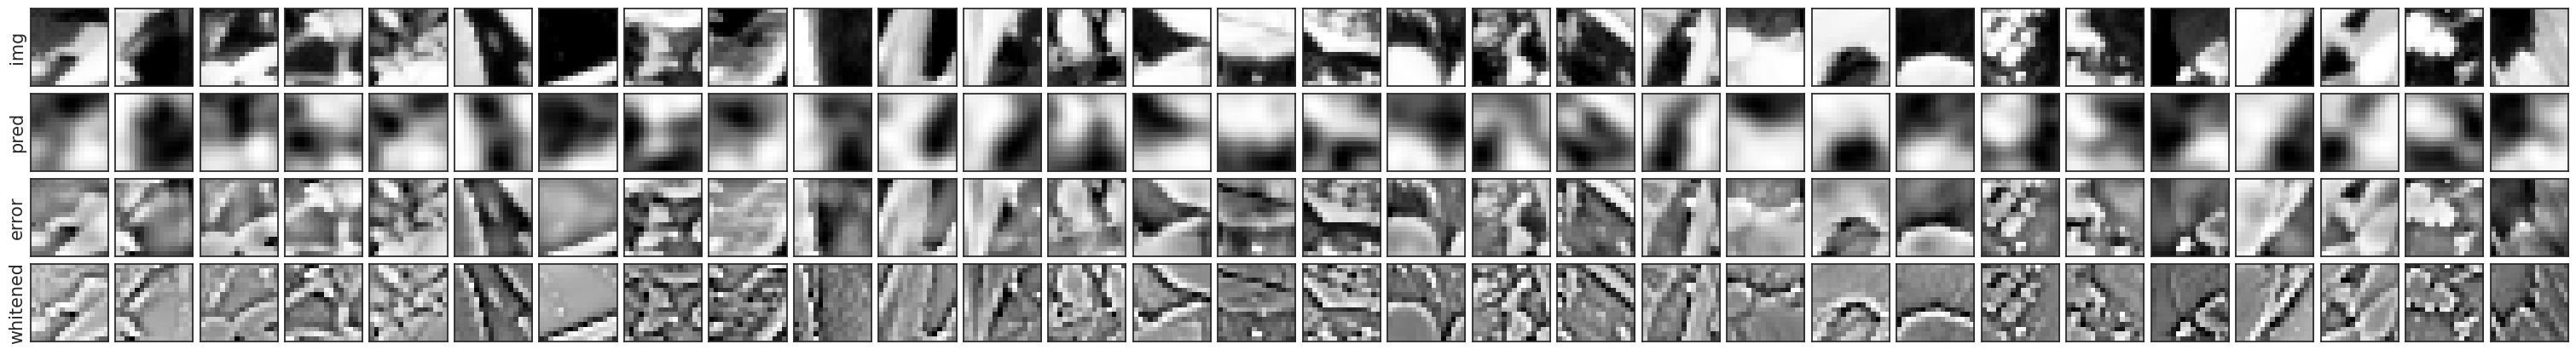

t = 5

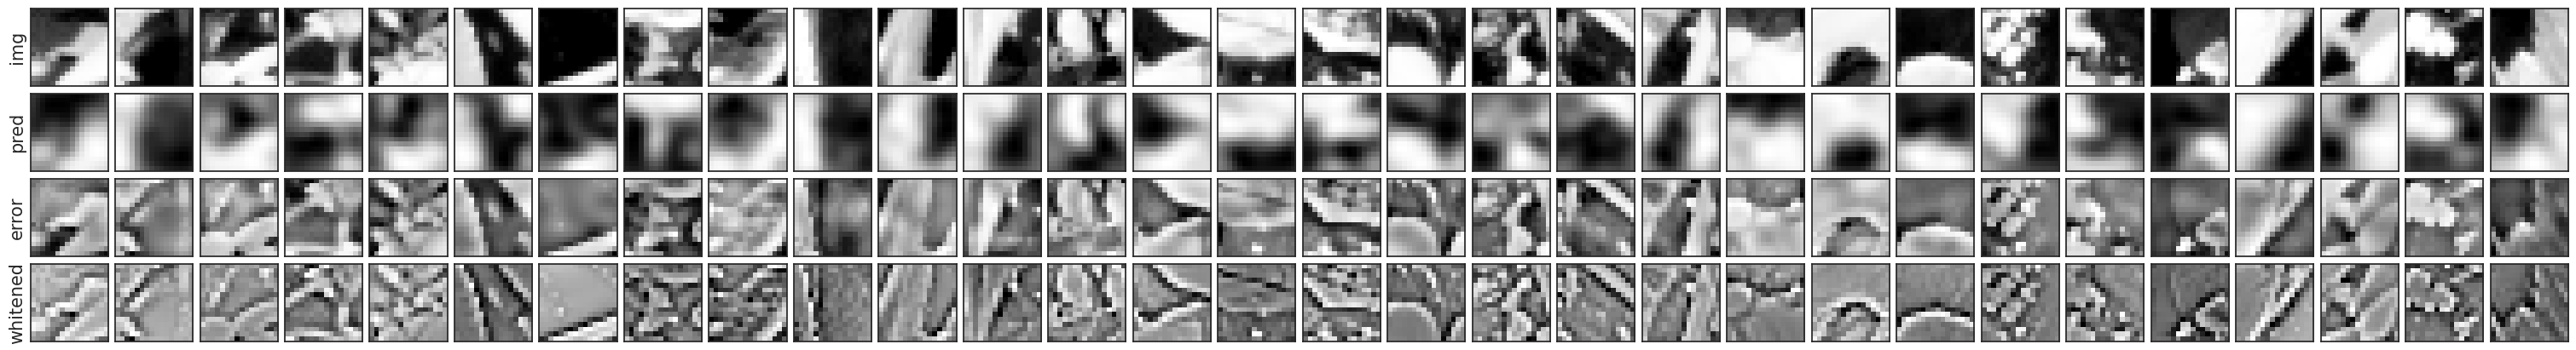

t = 6

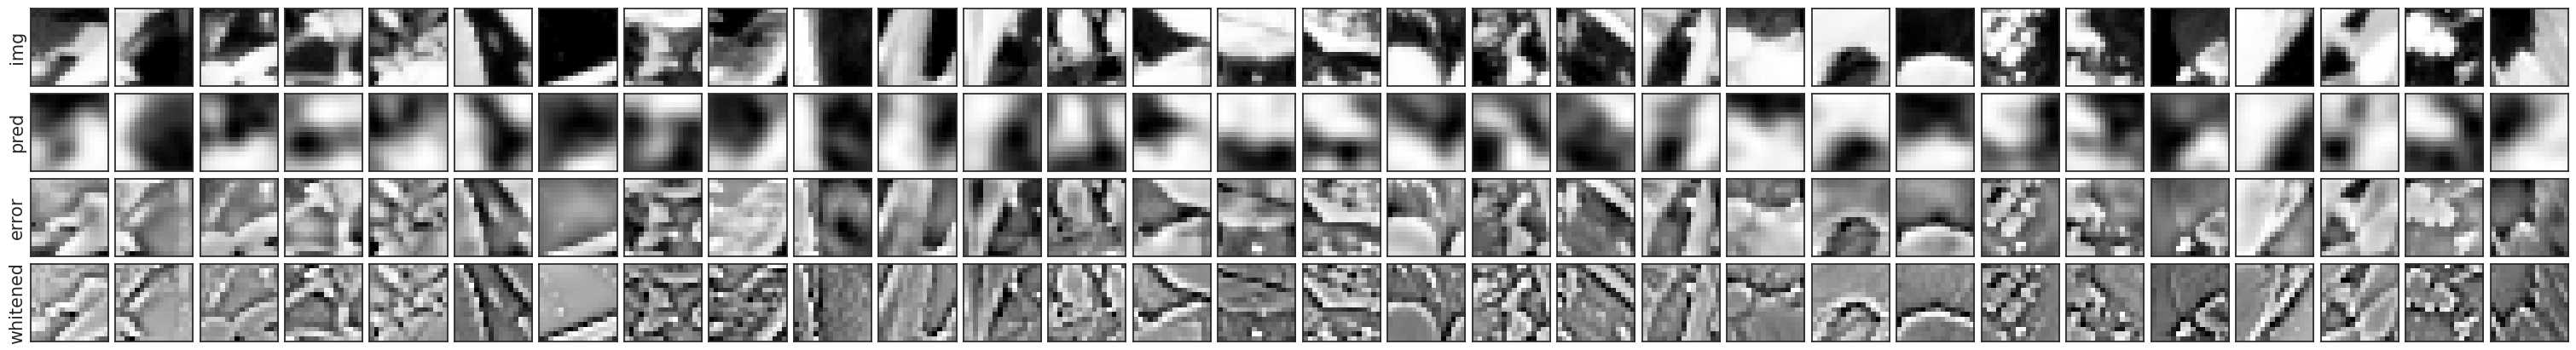

t = 7

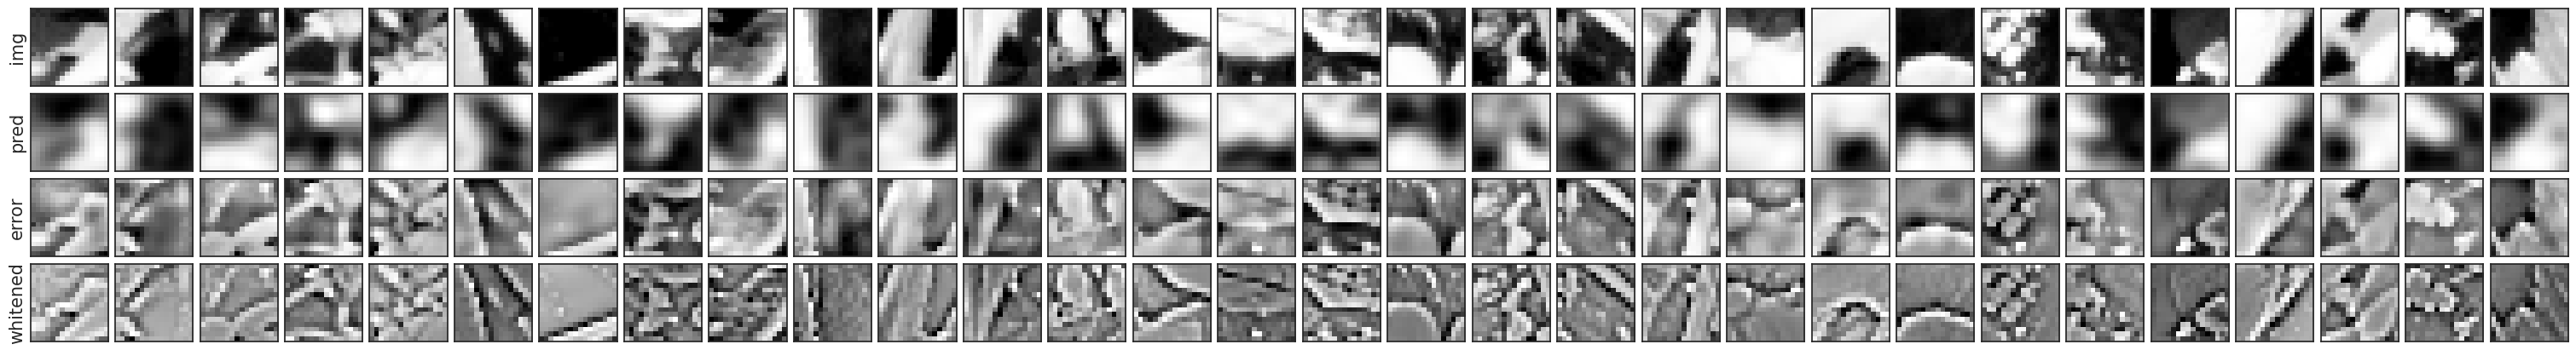

t = 8

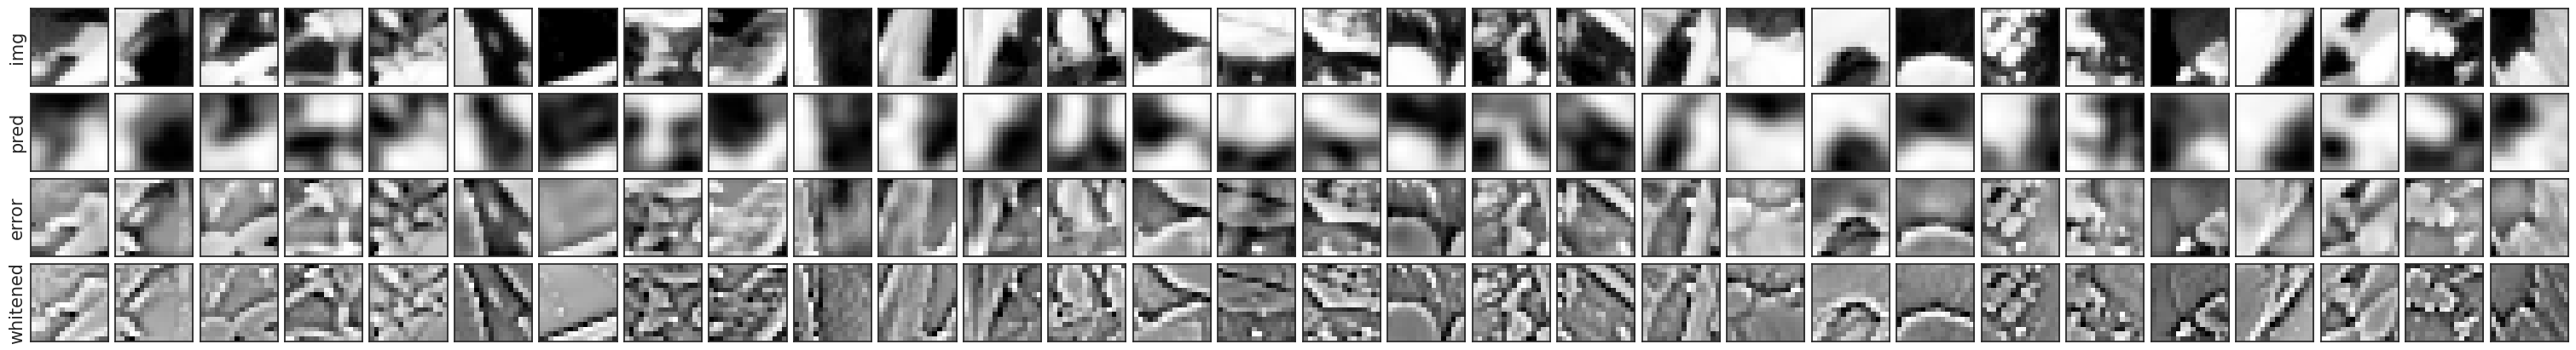

t = 9

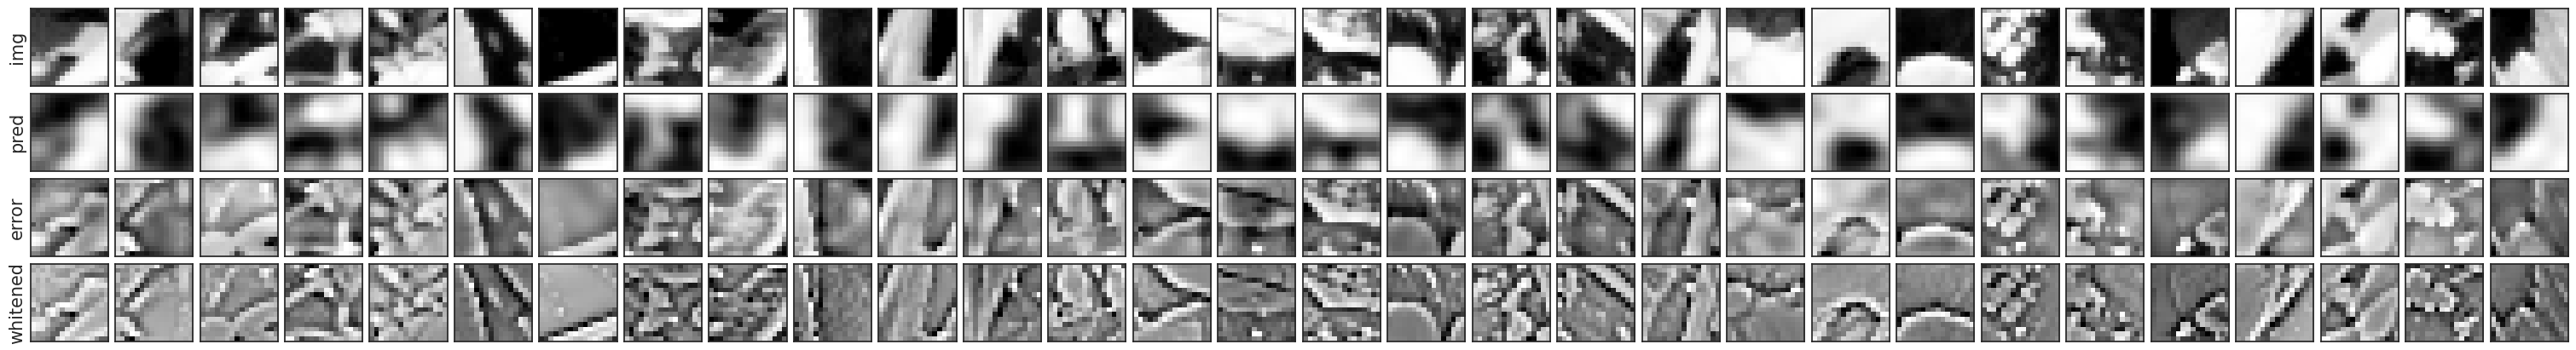

t = 10

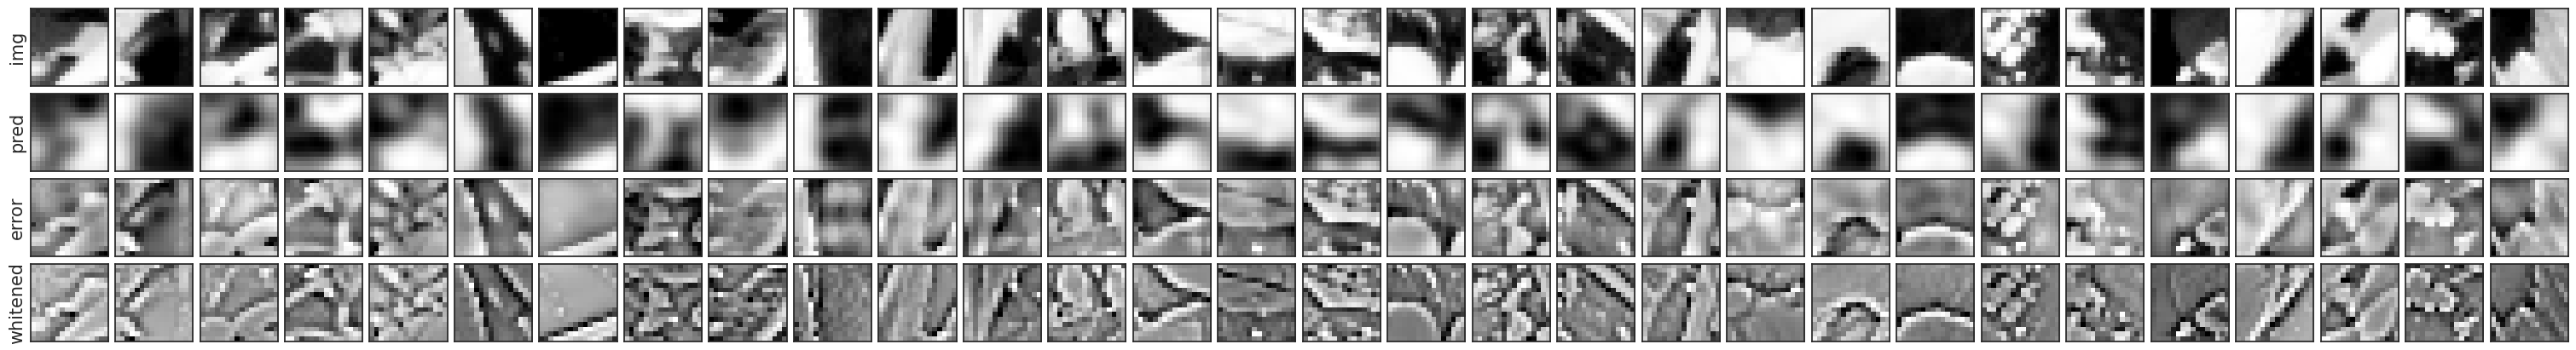

t = 11

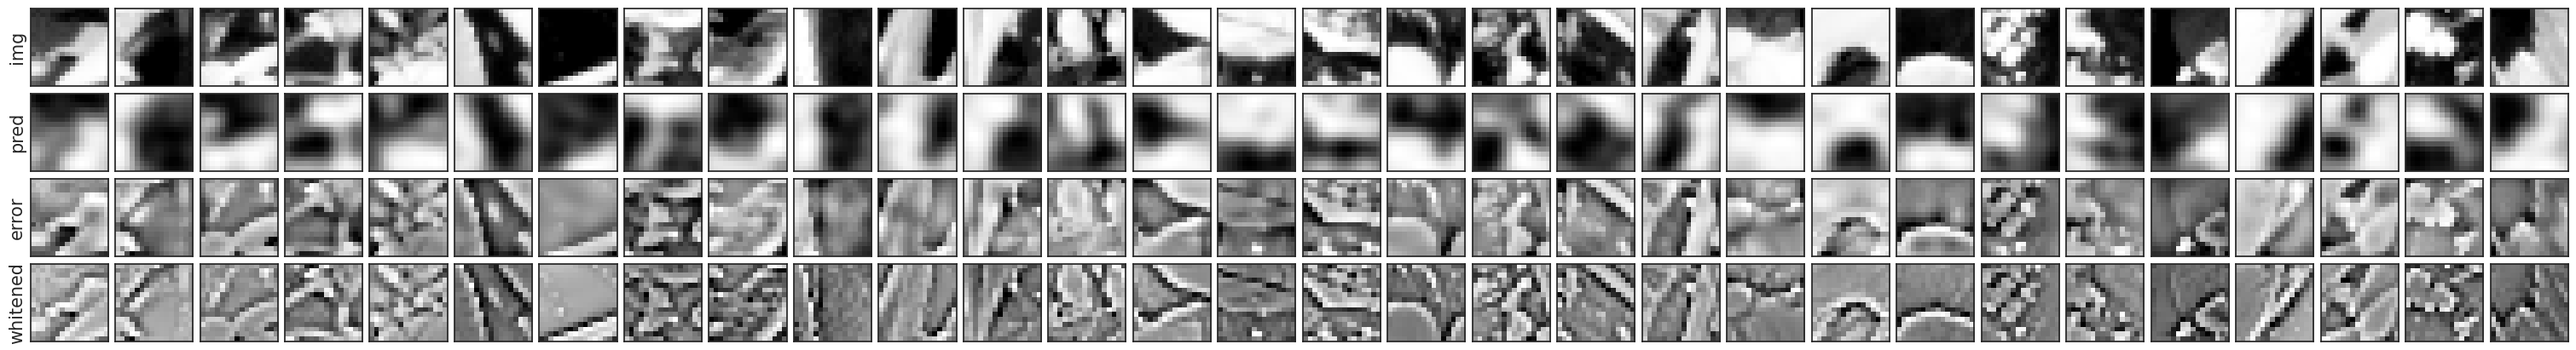

t = 12

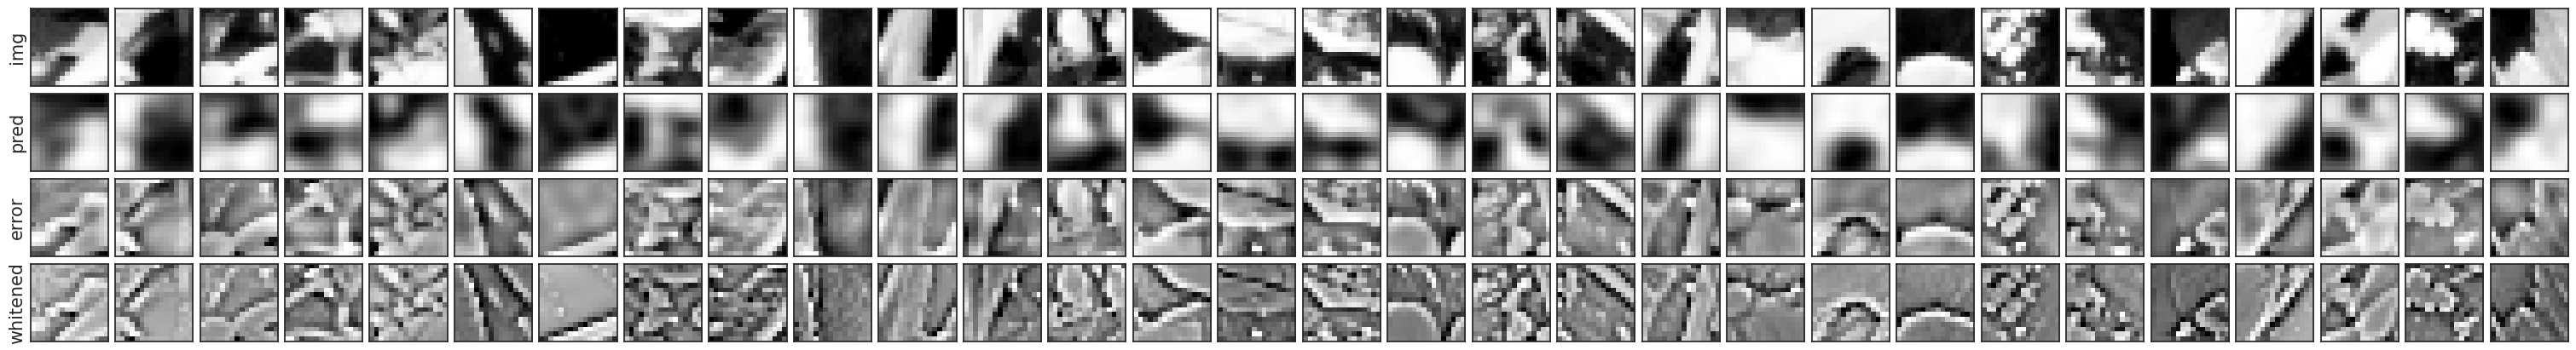

t = 13

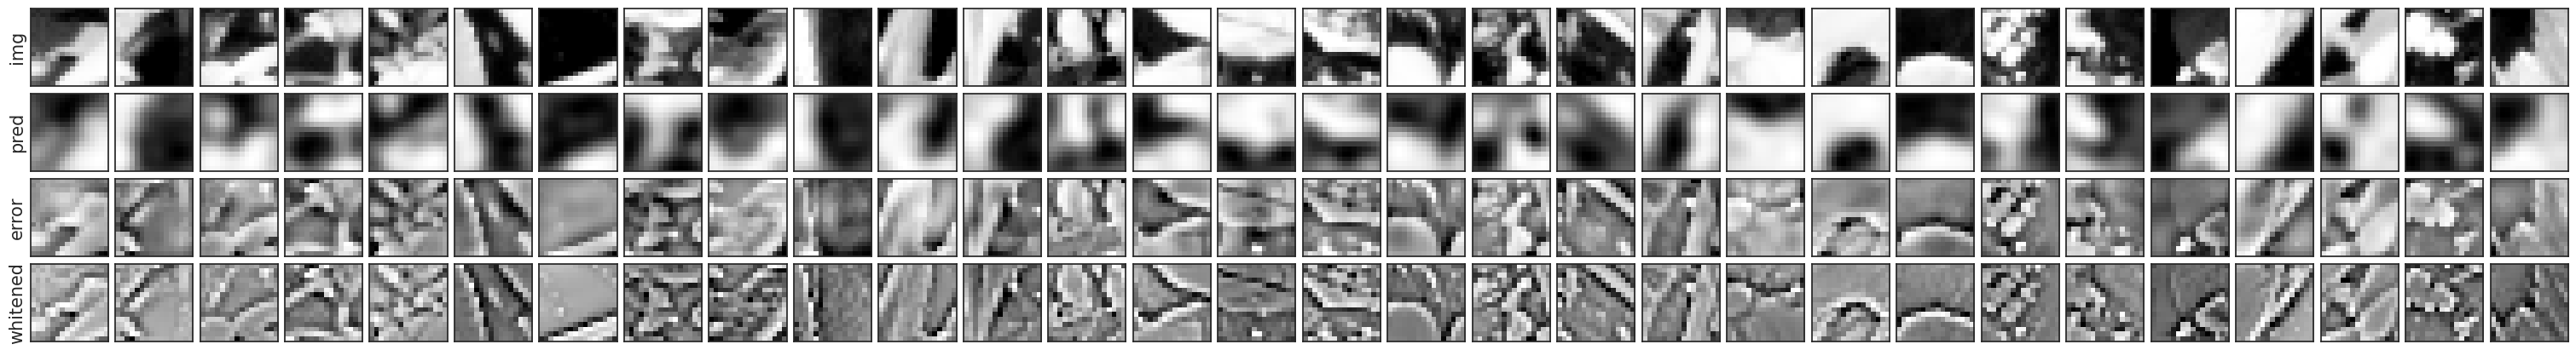

t = 14

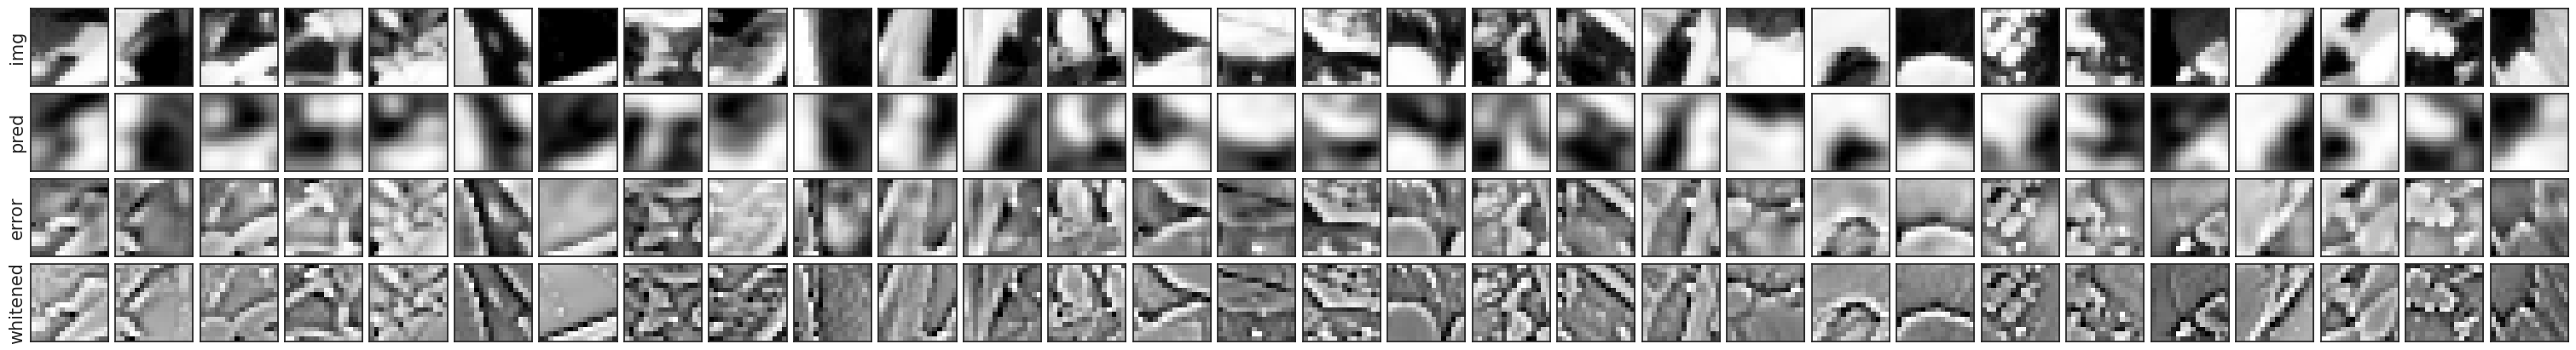

t = 15

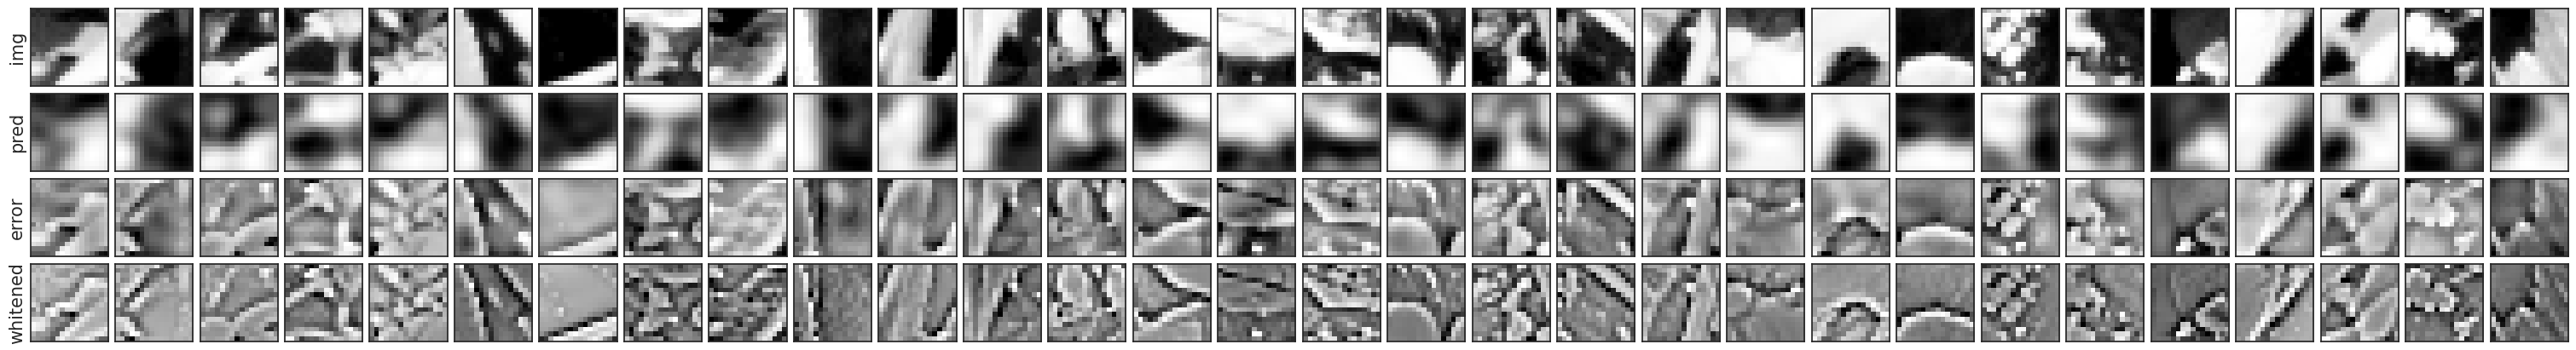

t = 16

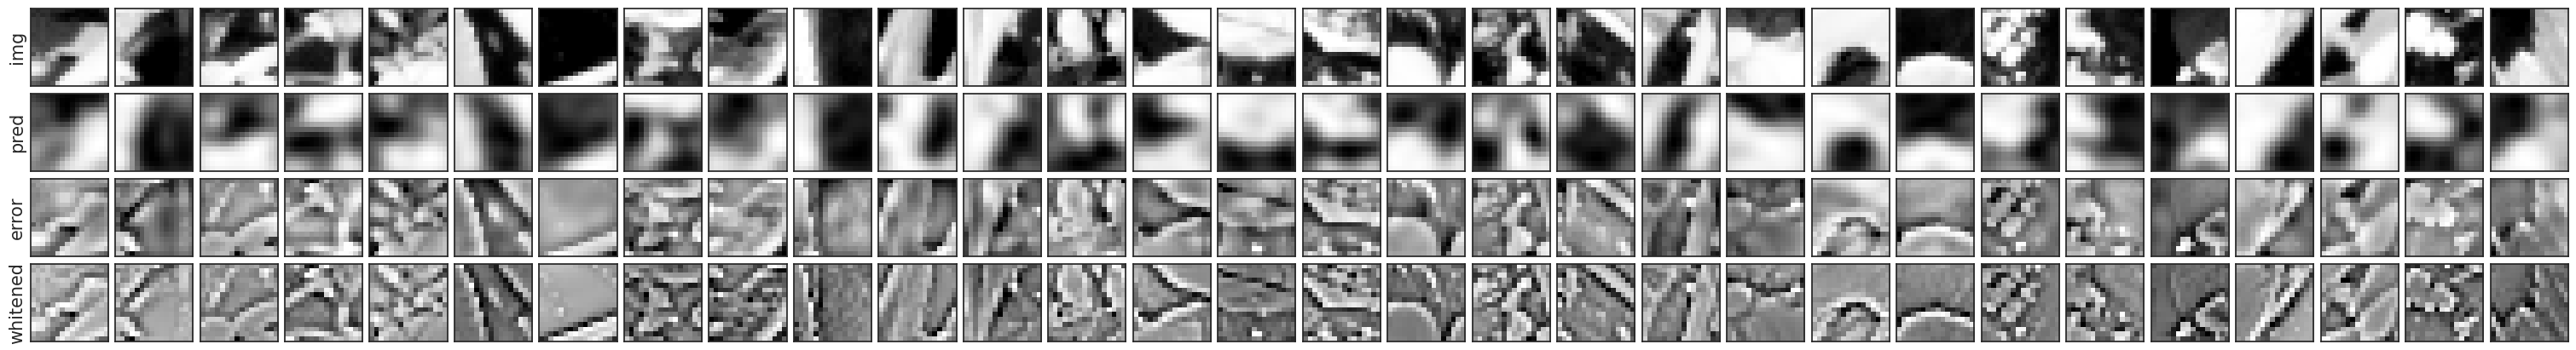

t = 17

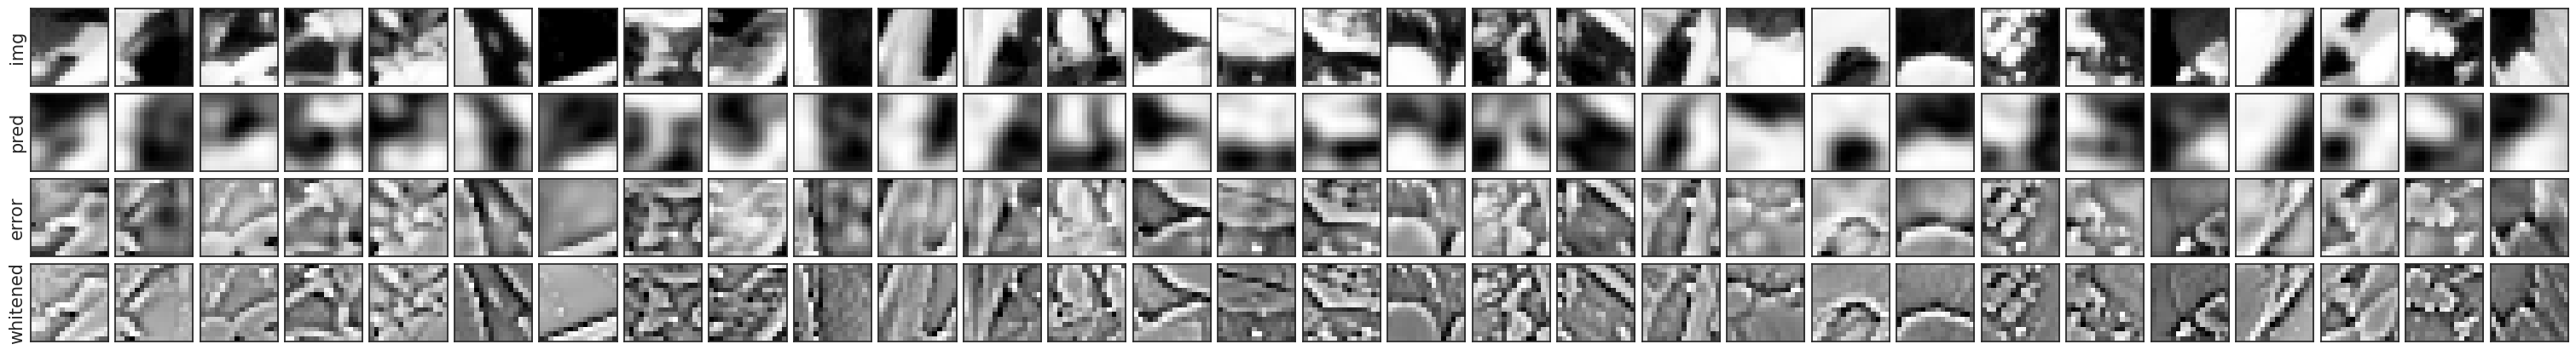

t = 18

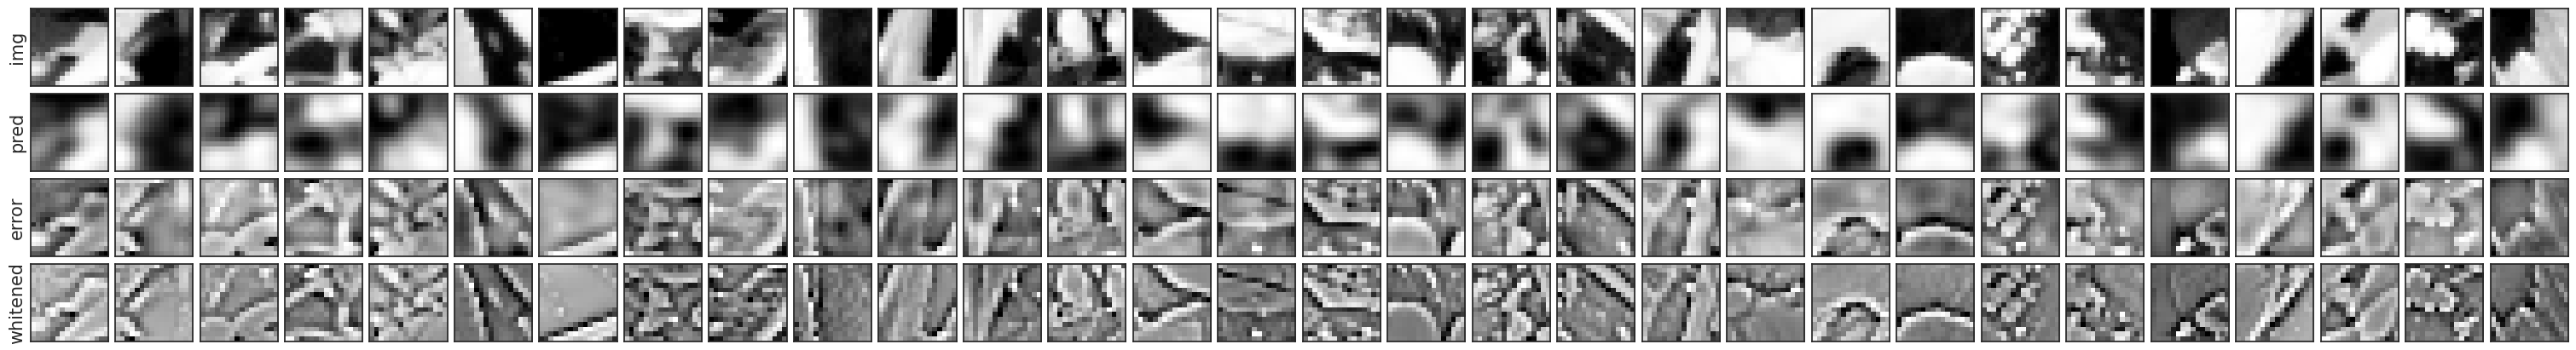

t = 19

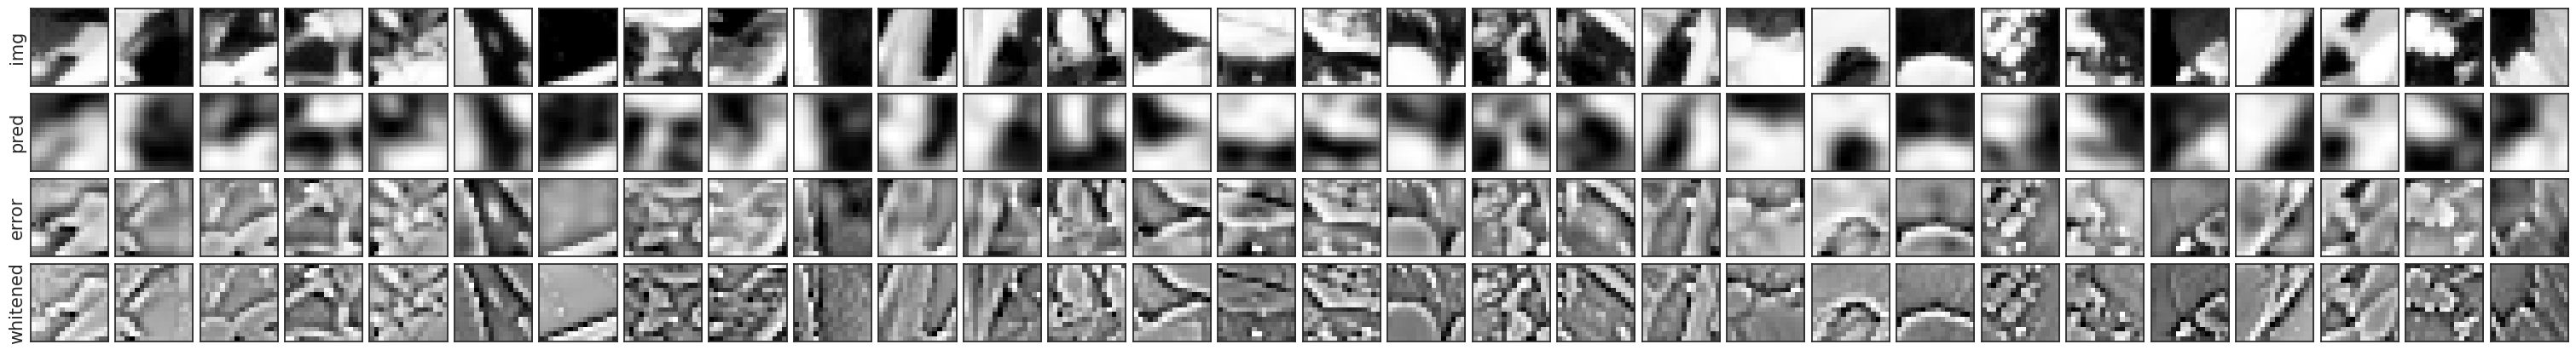

t = 20

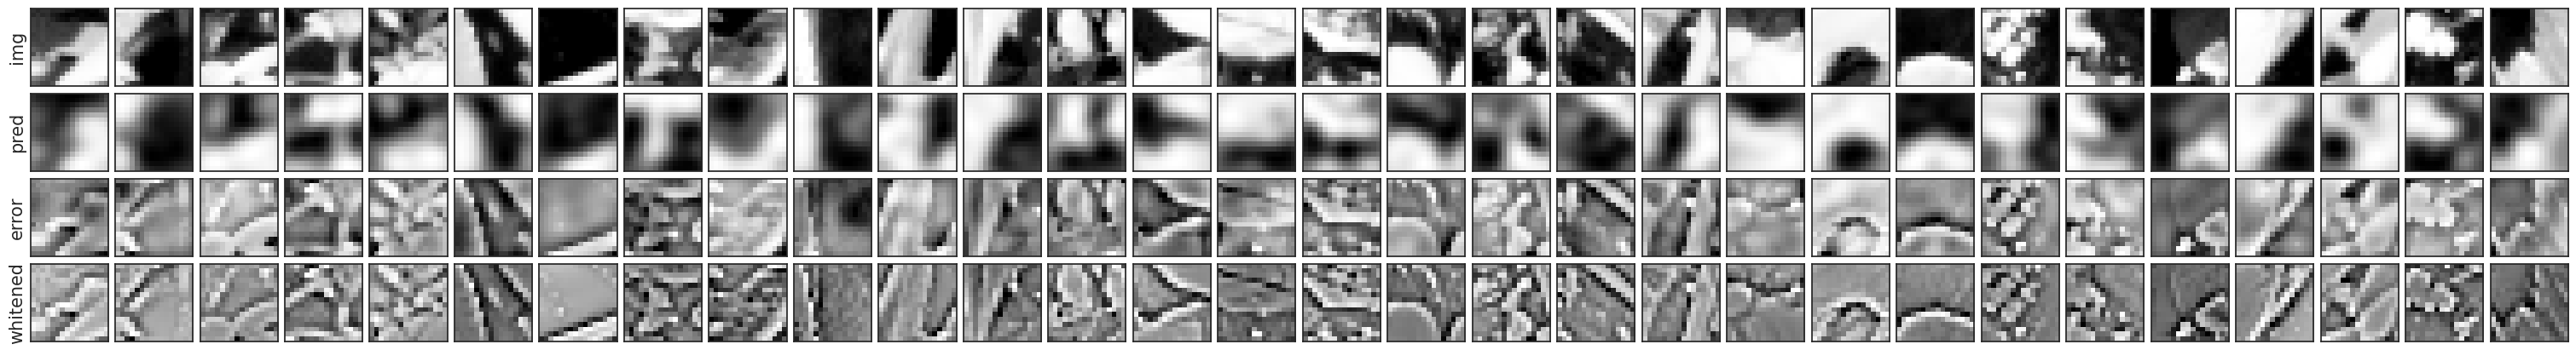

t = 21

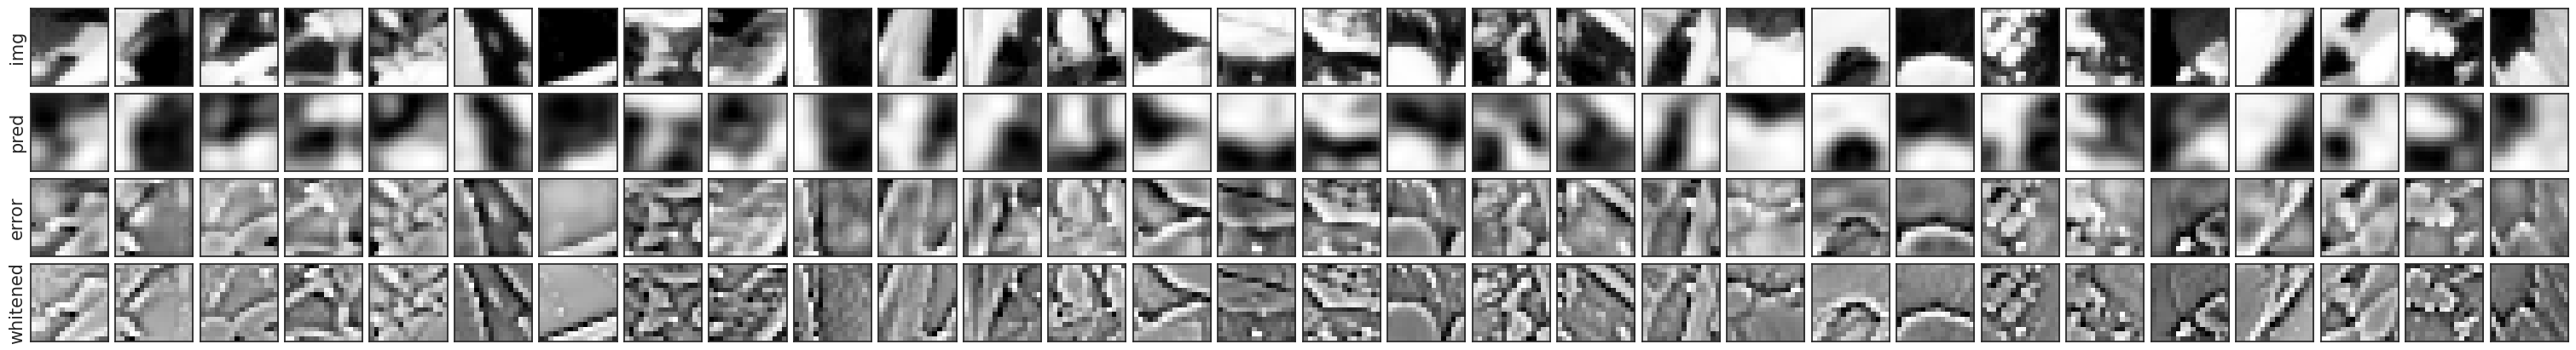

t = 22

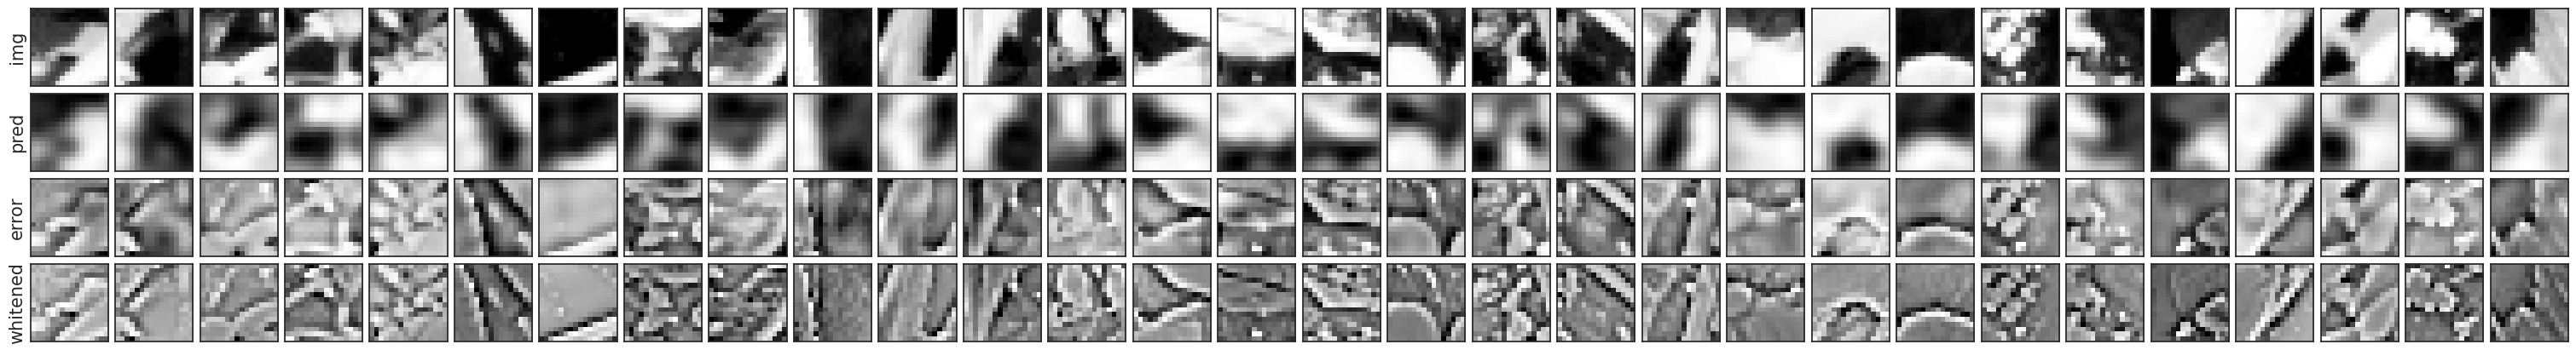

t = 23

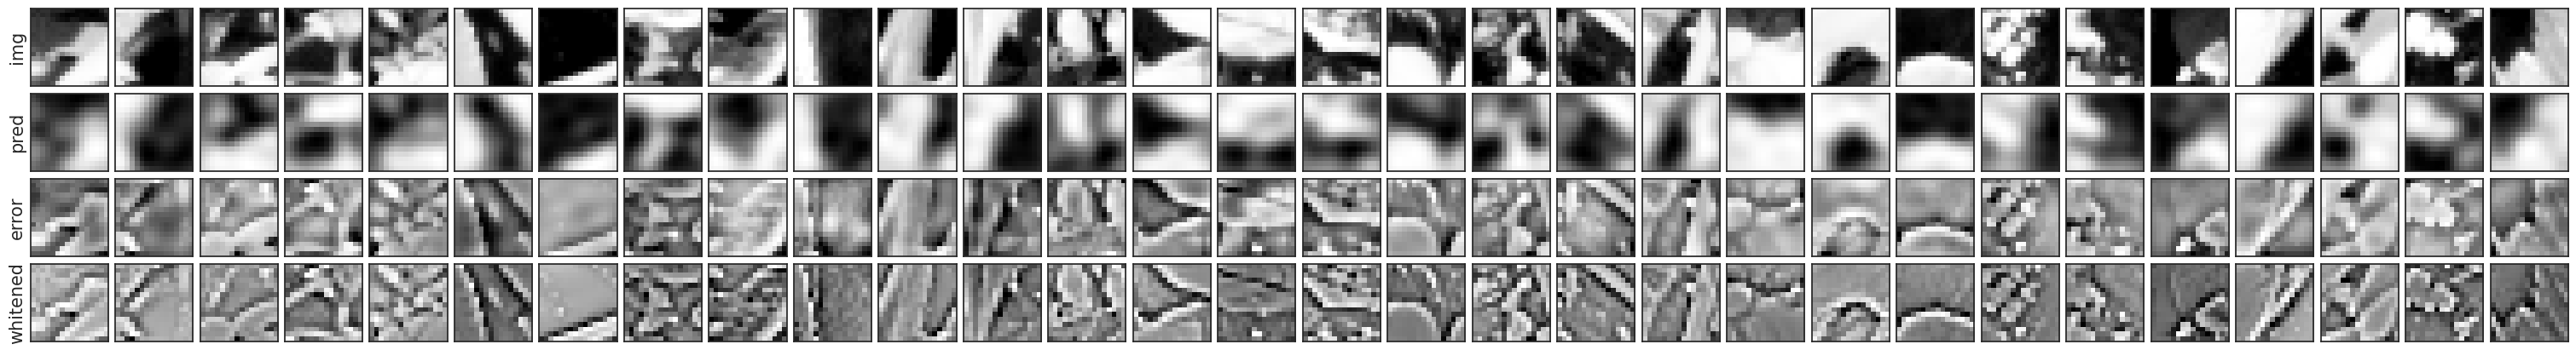

t = 24

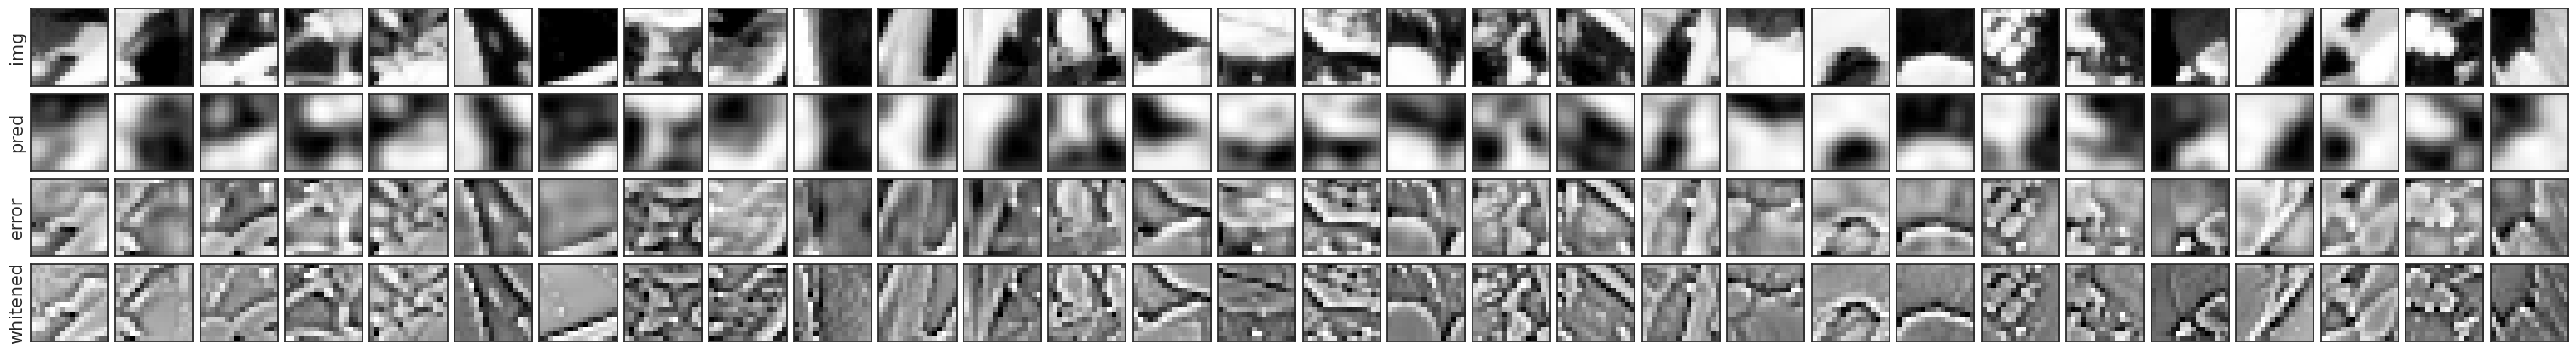

t = 25

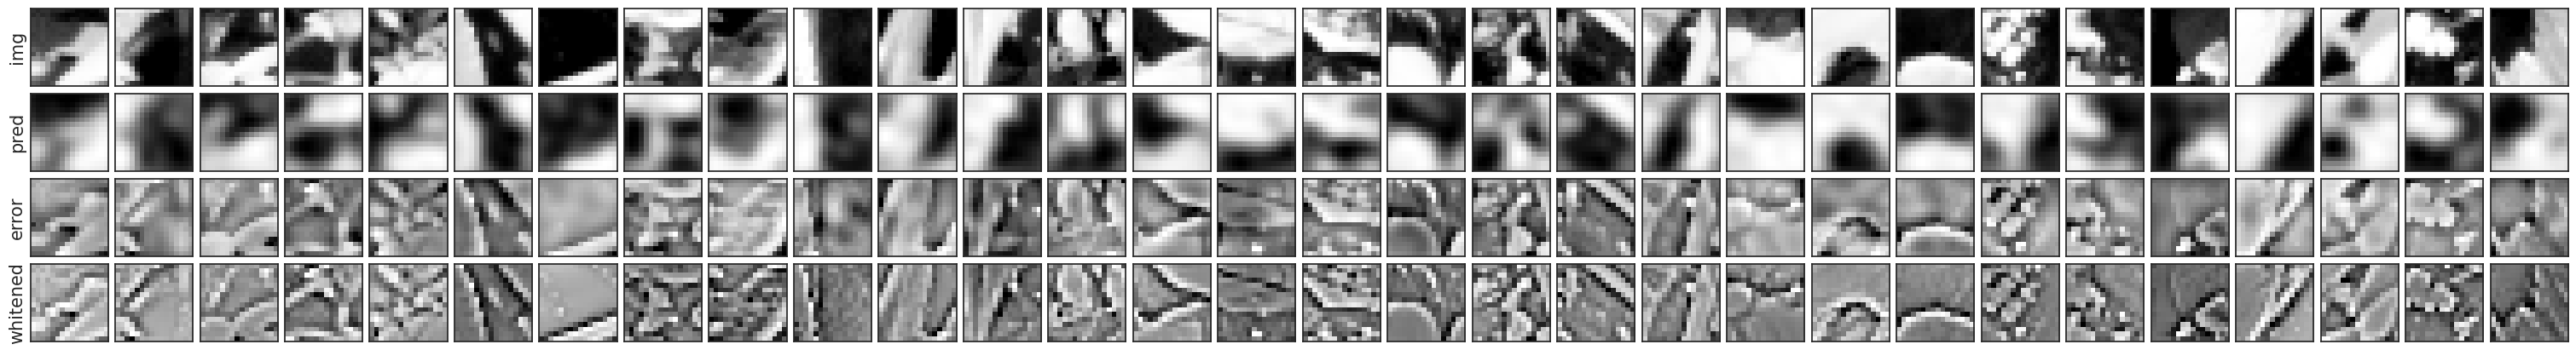

t = 26

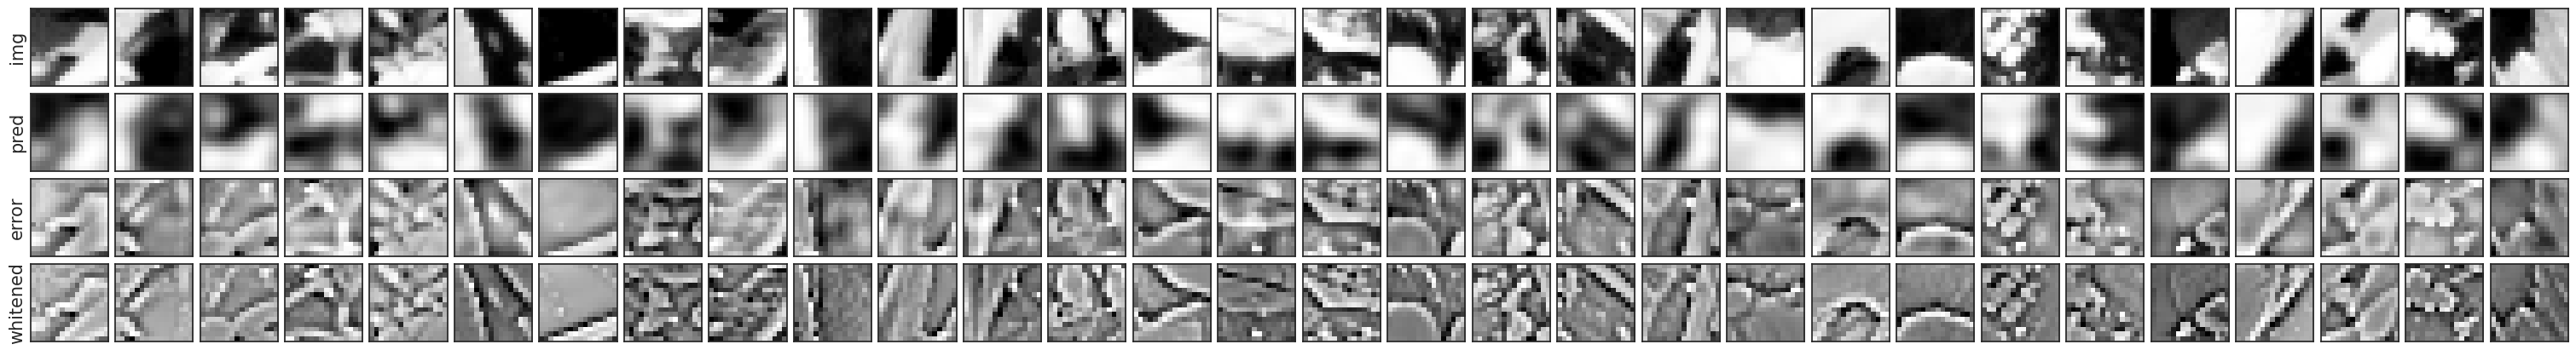

t = 27

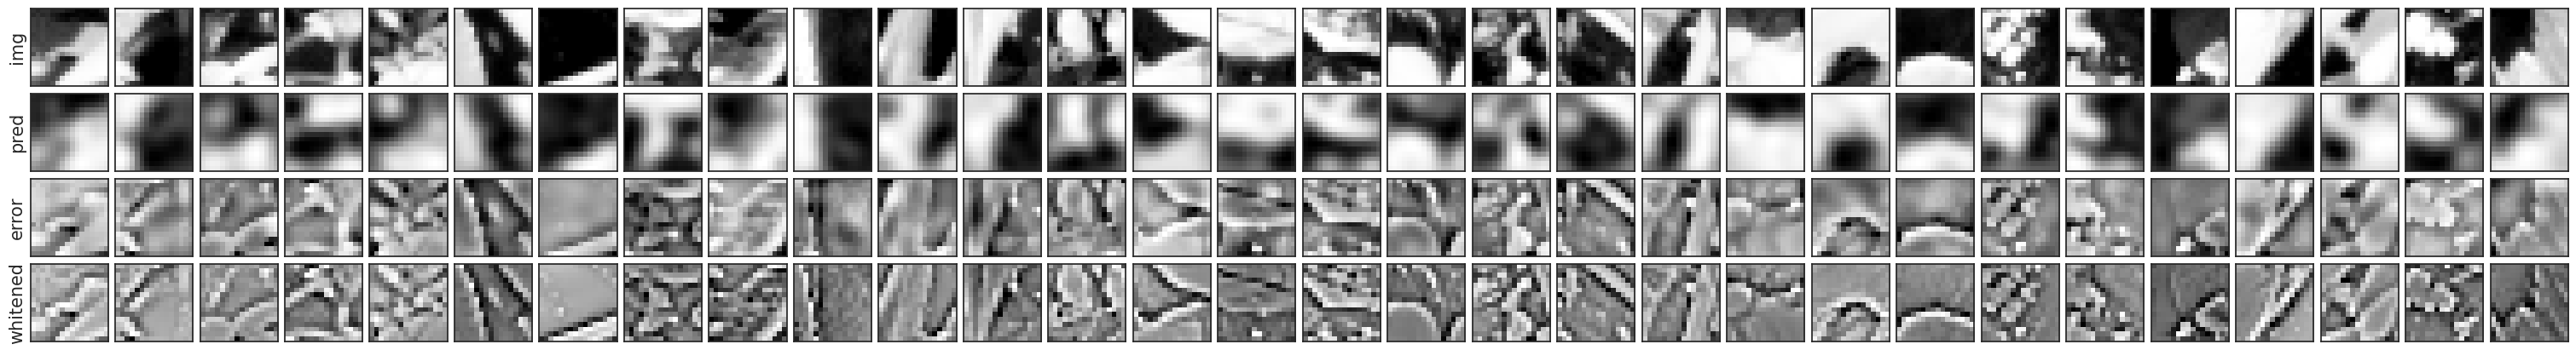

t = 28

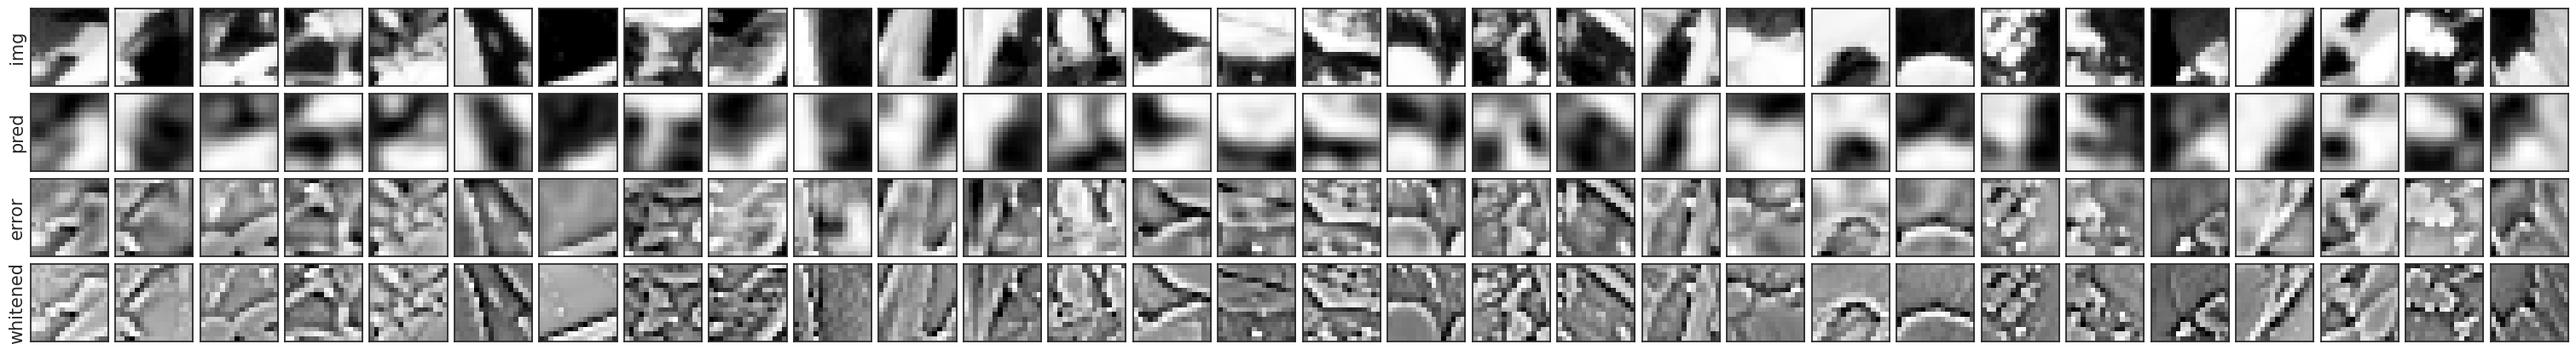

t = 29

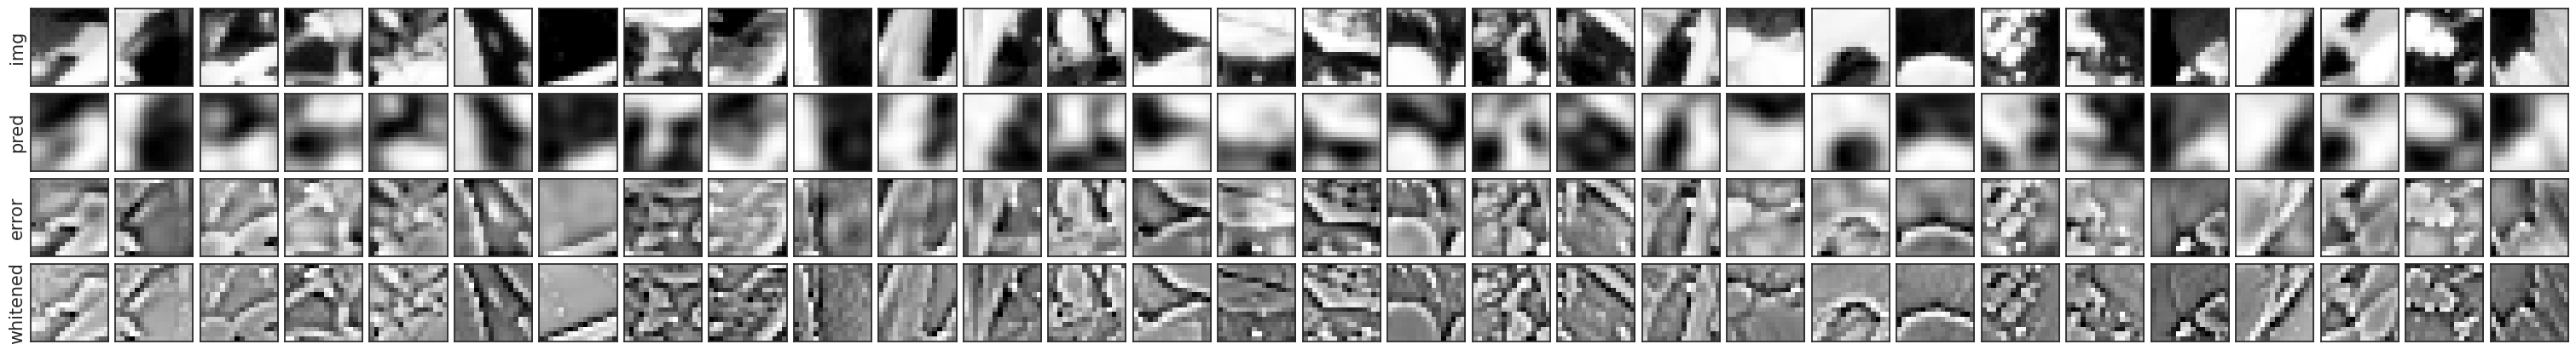

In [62]:
for t in range(30):
    print(f"t = {t}")
    conditional = output['conditional'][str(t)]
    pred = conditional.loc
    error = true - pred

    _plot_selected_samples(select_from=range(500))

In [65]:
corrs = []
for t in range(1000):
    conditional = output['conditional'][str(t)]
    pred = conditional.loc

    corr = sp_stats.pearsonr(
        tonp(pred.ravel()),
        tonp(whitened.ravel()),
    )
    corrs.append(corr.statistic)

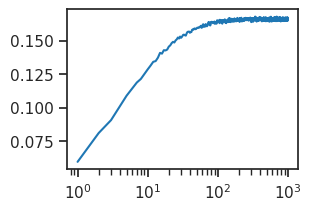

In [70]:
fig, ax = create_figure()
ax.plot(range(1, len(corrs) + 1),  corrs)
ax.set(xscale='log')
plt.show()

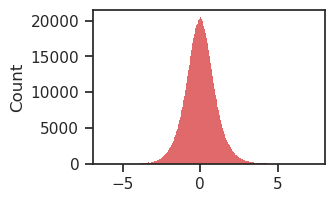

In [25]:
tmp = tonp(tmp.ravel())
sns.histplot(tmp, color='C3');

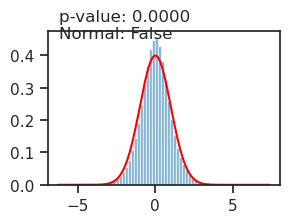

Shapiro-Wilk test: statistic=0.9938, p-value=0.0000

Data is not normal

In [30]:
mean = np.mean(tmp)
std = np.std(tmp)

# Fit Gaussian
x = np.linspace(min(tmp), max(tmp), 1000)
pdf = sp_stats.norm.pdf(x, mean, std)

# Test normality (null hypothesis: data comes from normal distribution)
stat, p = sp_stats.shapiro(tmp)
is_normal = p > 0.05

# Visualization
plt.hist(tmp, density=True, alpha=0.6, bins=70)
plt.plot(x, pdf, 'r-')
plt.text(0.05, 0.95, f'p-value: {p:.4f}\nNormal: {is_normal}', transform=plt.gca().transAxes)
plt.show()

print(f"Shapiro-Wilk test: statistic={stat:.4f}, p-value={p:.4f}")
print(f"Data is {'likely normal' if is_normal else 'not normal'}")